# Predicting Loan Default: A Machine Learning Approach to Credit Risk Assessment

**Author:** Atilla Ahmed
**Dataset:** Lending Club Loan Data (2007–2018), ~2.26M loans, 145 features

---

## Table of Contents
1. [Setup and Imports](#1-setup-and-imports)
2. [Introduction and Problem Formulation](#2-introduction-and-problem-formulation)
3. [Data Loading and Initial Inspection](#3-data-loading-and-initial-inspection)
4. [Data Cleaning and Preprocessing](#4-data-cleaning-and-preprocessing)
5. [Exploratory Data Analysis](#5-exploratory-data-analysis)
6. [Feature Engineering & Preprocessing Pipeline](#6-feature-engineering)
7. [Mathematical Framework](#7-mathematical-framework)
8. [Baseline Models](#8-baseline-models)
9. [Advanced Models and Hyperparameter Tuning](#9-advanced-models-and-hyperparameter-tuning)
10. [Model Evaluation and Comparison](#10-model-evaluation-and-comparison)
11. [Business Impact Analysis](#11-business-impact-analysis)
12. [Conclusions, Limitations, and Future Work](#12-conclusions-limitations-and-future-work)
13. [References](#13-references)

## 1. Setup and Imports <a id="1-setup-and-imports"></a>

All libraries and global settings are defined in one place so the notebook is fully reproducible. The random seed is fixed at 42 throughout.

In [1]:
# SETUP — libraries, global config, random seed

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     RandomizedSearchCV, cross_val_score)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, average_precision_score,
                              confusion_matrix, classification_report,
                              roc_curve, precision_recall_curve)
from scipy.stats import randint, uniform

SEED = 42
np.random.seed(SEED)


## 2. Introduction and Problem Formulation <a id="2-introduction-and-problem-formulation"></a>

### 2.1 Background

Lending Club was the largest peer-to-peer lending platform in the US. Investors lend money directly to borrowers, and the central risk they face is credit default a borrower stops repaying. When that happens the investor loses part or all of their principal. Predicting which borrowers will default is therefore critical for anyone deploying capital on the platform.

This project builds a classification model to predict loan default using only information available at the time of loan issuance. No post-origination data is used.

### 2.2 Problem Statement

**Task:** Binary classification - *Fully Paid* (0) vs *Charged Off / Default* (1).

**Target:** `loan_status`, filtered to loans with a known final outcome only.

**Key constraint:** Only features available at origination. Any variable that reflects what happened during repayment is excluded using those would be data leakage and would produce a model that works perfectly in training but fails entirely on new applications.

**Evaluation metric:** Accuracy is misleading on imbalanced datasets. Missing a default costs real money; rejecting a good borrower costs opportunity. This asymmetry makes Recall and PR-AUC far more relevant.

### 2.3 Expected Loss Framework

$$\text{Expected Loss} = PD \times LGD \times EAD$$

- **PD (Probability of Default)** - the likelihood a borrower fails to repay. This is what the model predicts.
- **LGD (Loss Given Default)** - the fraction of the outstanding amount that is not recovered. Typically 40–60% for unsecured consumer loans.
- **EAD (Exposure at Default)** - the total amount owed at the time of default.

The model targets the PD component. A well-calibrated PD estimate allows a lender to price risk correctly and make informed accept/reject decisions on new applications.

## 3. Data Loading and Initial Inspection <a id="3-data-loading-and-initial-inspection"></a>

The dataset is a single 1.1 GB CSV file with 2.26 million loan records and 145 columns. A data dictionary is included as a separate Excel file.

In [2]:
loans = pd.read_csv('loan.csv', low_memory=False)
print(f'Shape: {loans.shape[0]:,} rows x {loans.shape[1]} columns')

Shape: 2,260,668 rows x 145 columns


In [3]:
loans.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,NaN,NaN,2500,2500,2500.0,36 months,13.56,84.92,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,30000,30000,30000.0,60 months,18.94,777.23,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,5000,5000,5000.0,36 months,17.97,180.69,D,D1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,4000,4000,4000.0,36 months,18.94,146.51,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,30000,30000,30000.0,60 months,16.14,731.78,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
loans.info(verbose=True, show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 2260668 entries, 0 to 2260667
Data columns (total 145 columns):
 #    Column                                      Non-Null Count    Dtype  
---   ------                                      --------------    -----  
 0    id                                          0 non-null        float64
 1    member_id                                   0 non-null        float64
 2    loan_amnt                                   2260668 non-null  int64  
 3    funded_amnt                                 2260668 non-null  int64  
 4    funded_amnt_inv                             2260668 non-null  float64
 5    term                                        2260668 non-null  str    
 6    int_rate                                    2260668 non-null  float64
 7    installment                                 2260668 non-null  float64
 8    grade                                       2260668 non-null  str    
 9    sub_grade                                   2260668 non

### 3.1 Target Variable Distribution

Before doing anything else I need to understand what `loan_status` contains and decide which values map to default vs non-default.

In [5]:
(loans['loan_status'].value_counts(normalize=True).round(4) * 100)

loan_status
Fully Paid                                             46.09
Current                                                40.68
Charged Off                                            11.57
Late (31-120 days)                                      0.97
In Grace Period                                         0.40
Late (16-30 days)                                       0.17
Does not meet the credit policy. Status:Fully Paid      0.09
Does not meet the credit policy. Status:Charged Off     0.03
Default                                                 0.00
Name: proportion, dtype: float64

Looking at the distribution, a few things stand out:

- **Current (40.7%)** - these loans are still active. The outcome is unknown, so they have to be excluded.
- **Fully Paid (46.1%)** - borrower repaid in full → class 0.
- **Charged Off (11.6%)** - lender wrote off the debt → class 1.
- **Late / In Grace Period (1.5%)** - delinquent but not yet charged off. Ambiguous label, so excluded to avoid noise.
- The remaining categories (`Does not meet credit policy`, `Default`) are either negligible or will be mapped to their obvious outcome.

I keep only *Fully Paid* and *Charged Off* as the two definitive outcomes. Everything else is excluded.

### 3.2 Missing Values Overview

With 145 columns there will be significant gaps. This analysis is run on the raw dataset to get a baseline before any filtering. Worth noting: the effective missing rate for some columns will shift after I filter to known outcomes in Section 4, which is why I re-check missing values on the filtered data before deciding what to drop.

In [6]:
missing_raw = loans.isna().sum()
missing_pct_raw = (missing_raw / len(loans) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing' : missing_raw,
    'Percent' : missing_pct_raw
}).sort_values('Percent', ascending=False)

missing_df[missing_df['Missing'] > 0]

,Missing,Percent
id,2260668,100.00
url,2260668,100.00
member_id,2260668,100.00
orig_projected_additional_accrued_interest,2252242,99.63
hardship_length,2250055,99.53
...,...,...
acc_now_delinq,29,0.00
last_credit_pull_d,73,0.00
tax_liens,105,0.00
total_acc,29,0.00


Quick summary of how severe the missingness is:

In [7]:
total_cols = loans.shape[1]
empty_cols = (missing_pct_raw == 100).sum()
over_90 = (missing_pct_raw > 90).sum()
over_50 = (missing_pct_raw > 50).sum()

print(f'Total columns:         {total_cols}')
print(f'Completely empty:      {empty_cols}')
print(f'Over 90% missing:      {over_90}')
print(f'Over 50% missing:      {over_50}')

Total columns:         145
Completely empty:      3
Over 90% missing:      38
Over 50% missing:      44


Three columns are completely empty - `id`, `url`, `member_id` - stripped for privacy. The 38 columns above 90% missing are mostly hardship and settlement details that only exist for a small fraction of borrowers who entered those programs. The 44 columns above 50% include joint application fields populated only for co-borrowers, which is about 5% of loans.

Columns above 50% missing will be dropped, but the threshold will be re-evaluated after filtering.

## 4. Data Cleaning and Preprocessing <a id="4-data-cleaning-and-preprocessing"></a>

The raw dataset needs several rounds of cleaning before it is usable. I follow a deliberate order: filter first, then recheck missing rates, then drop, then convert types, then impute. Doing it in any other sequence can produce incorrect missing percentages or introduce subtle errors.

In [8]:
data_columns = loans.columns.to_list()

In [9]:
keep_status = [
    'Fully Paid',
    'Charged Off',
    'Default',
    'Does not meet the credit policy. Status:Fully Paid',
    'Does not meet the credit policy. Status:Charged Off'
]

loans = loans[loans['loan_status'].isin(keep_status)].copy()
print(f'Rows after filtering: {loans.shape[0]:,}')
print()
print(loans['loan_status'].value_counts())

Rows after filtering: 1,306,387

loan_status
Fully Paid                                             1041952
Charged Off                                             261655
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     31
Name: count, dtype: int64


### 4.2 Create Binary Target

In [10]:
default_statuses = [
    'Charged Off',
    'Default',
    'Does not meet the credit policy. Status:Charged Off'
]
loans['target'] = loans['loan_status'].isin(default_statuses).astype(int)

print(loans['target'].value_counts())
print()
print('Default rate:', f"{loans['target'].mean():.4f}")

target
0    1043940
1     262447
Name: count, dtype: int64

Default rate: 0.2009


### 4.3 Re-Compute Missing Rates on the Filtered Dataset

 Filtering toward known outcomes shifts the composition toward newer records, which can reduce apparent missingness. Re-computing on the 1.3M filtered rows ensures the 50% threshold reflects the data that will actually be used.

In [11]:
missing_filtered = loans.isna().sum()
missing_pct_filtered = (missing_filtered / len(loans) * 100).round(2)

missing_filtered_df = pd.DataFrame({
    'Missing' : missing_filtered,
    'Percent' : missing_pct_filtered
}).sort_values('Percent', ascending=False)

print('Columns with missing values after filtering:')
print(missing_filtered_df[missing_filtered_df['Missing'] > 0].to_string())

Columns with missing values after filtering:
                                            Missing  Percent
id                                          1306387   100.00
member_id                                   1306387   100.00
url                                         1306387   100.00
next_pymnt_d                                1303607    99.79
orig_projected_additional_accrued_interest  1302954    99.74
payment_plan_start_date                     1301052    99.59
hardship_type                               1301052    99.59
hardship_reason                             1301052    99.59
hardship_status                             1301052    99.59
deferral_term                               1301052    99.59
hardship_amount                             1301052    99.59
hardship_start_date                         1301052    99.59
hardship_end_date                           1301052    99.59
hardship_length                             1301052    99.59
hardship_dpd                            

### 4.4 Drop Unusable Columns

I split the columns to drop into four groups, each with a distinct reason:

**A) High-missing (>50% on filtered dataset)** - not enough data to impute reliably.

**B) Post-origination / leakage** - these variables only exist after a loan outcome has occurred. Using them would let the model see the future, producing inflated training metrics and a model that is completely useless on new applications.

**C) Zero-variance** - constant values carry no information and can destabilise some algorithms.

**D) Identifiers and free-text** - IDs, URLs, and unstructured text fields.

In [12]:
high_missing = missing_pct_filtered[missing_pct_filtered > 50].index.to_list()
print(f'A) High missing (>50%): {len(high_missing)} columns')

A) High missing (>50%): 58 columns


In [13]:
# Post-origination leakage none of these exist at loan origination
leakage_cols = [
    'out_prncp', 'out_prncp_inv',            # remaining principal — only known during repayment
    'total_pymnt', 'total_pymnt_inv',         # total payments received
    'total_rec_prncp', 'total_rec_int',       # principal and interest received
    'total_rec_late_fee',                      # late fees — only exist after missed payments
    'recoveries', 'collection_recovery_fee',  # post charge-off recovery amounts
    'last_pymnt_d', 'last_pymnt_amnt',        # last payment date and amount
    'next_pymnt_d',                            # next scheduled payment
    'last_credit_pull_d',                      # last time LC pulled credit
    'loan_status',                             # original target column
    'hardship_flag',                           # whether borrower entered a hardship program
    'debt_settlement_flag',                    # whether borrower entered debt settlement
    'disbursement_method',                     # how the loan was paid out — post-approval
    'pymnt_plan',                              # active payment plan — only set after repayment difficulty
]
print(f'B) Post-origination / leakage: {len(leakage_cols)} columns')

B) Post-origination / leakage: 18 columns


In [14]:
# Zero-variance constant across the entire dataset, no predictive signal
zero_variance_cols = [
    'policy_code',        # always 1 in the public dataset
    'initial_list_status' # LC internal listing flag, negligible signal
]
print(f'C) Zero-variance: {len(zero_variance_cols)} columns')

C) Zero-variance: 2 columns


In [15]:
irrelevant_cols = [
    'id', 'member_id', 'url',   # identifiers, all empty
    'emp_title',                 # free text, 300K+ unique values
    'title',                     # free text loan title, redundant with purpose
    'desc',                      # free text description, 94% missing
    'zip_code',                  # partial 3-digit zip, too granular
    'issue_d',                   # loan issue date temporal leakage if used as feature
]
print(f'D) Identifiers / irrelevant: {len(irrelevant_cols)} columns')

D) Identifiers / irrelevant: 8 columns


In [16]:
drop_cols = list(set(high_missing + leakage_cols + zero_variance_cols + irrelevant_cols))
print(f'Total unique columns to drop: {len(drop_cols)}')

loans.drop(columns=[c for c in drop_cols if c in loans.columns], inplace=True)
print(f'Remaining: {loans.shape[1]} columns')

Total unique columns to drop: 81
Remaining: 65 columns


### 4.5 Data Type Conversions

Several columns are stored as strings but contain numeric or categorical information.

In [17]:
str_cols = loans.select_dtypes(include='object').columns.to_list()
print(f'String columns: {len(str_cols)}')
print()
for col in str_cols:
    n_unique = loans[col].nunique()
    sample = loans[col].dropna().iloc[0] if loans[col].notna().any() else 'N/A'
    print(f'  {col:30s} {n_unique:>6} unique   example: {sample}')

String columns: 10

  term                                2 unique   example:  36 months
  grade                               7 unique   example: D
  sub_grade                          35 unique   example: D5
  emp_length                         11 unique   example: 5 years
  home_ownership                      6 unique   example: MORTGAGE
  verification_status                 3 unique   example: Source Verified
  purpose                            14 unique   example: debt_consolidation
  addr_state                         51 unique   example: CA
  earliest_cr_line                  738 unique   example: Jan-2012
  application_type                    2 unique   example: Joint App


In [18]:
# term: " 36 months" → 36
loans['term'] = loans['term'].str.strip().str.replace(' months', '').astype(int)
print(loans['term'].value_counts())

term
36    991212
60    315175
Name: count, dtype: int64


In [19]:
# emp_length: "10+ years" → 10, "< 1 year" → 0
loans['emp_length'] = (
    loans['emp_length']
    .str.replace(r'\+?\s*years?', '', regex=True)
    .str.replace('< 1', '0')
    .str.strip()
)
loans['emp_length'] = pd.to_numeric(loans['emp_length'], errors='coerce')
print(f'emp_length missing: {loans["emp_length"].isnull().sum():,}')

emp_length missing: 75,491


In [20]:
# earliest_cr_line: "Jan-2012" → years of credit history
# A raw date isn't useful as a feature. The number of years since the oldest
# credit line is a direct signal longer history generally means lower risk.
loans['earliest_cr_line'] = pd.to_datetime(loans['earliest_cr_line'], format='%b-%Y')
loans['credit_history_years'] = (
    (pd.Timestamp('2018-12-01') - loans['earliest_cr_line']).dt.days / 365.25
).round(1)
loans.drop(columns='earliest_cr_line', inplace=True)
print(loans['credit_history_years'].describe())

count    1.306358e+06
mean     1.978993e+01
std      7.591897e+00
min      3.200000e+00
25%      1.450000e+01
50%      1.840000e+01
75%      2.370000e+01
max      8.470000e+01
Name: credit_history_years, dtype: float64


### 4.6 Convert Categorical Columns

The remaining string columns are categorical. Converting to `category` dtype reduces memory usage.

In [21]:
cat_cols = ['sub_grade', 'home_ownership', 'verification_status',
            'purpose', 'addr_state', 'application_type']

for col in cat_cols:
    if col in loans.columns:
        loans[col] = loans[col].astype('category')

print(f'Memory: {loans.memory_usage(deep=True).sum() / 1e9:.2f} GB')
print(f'Categorical columns: {loans.select_dtypes(include="category").columns.tolist()}')

Memory: 0.63 GB
Categorical columns: ['sub_grade', 'home_ownership', 'verification_status', 'purpose', 'addr_state', 'application_type']


### 4.7 Handle Missing Values

Not all missing values mean the same thing. `mths_since_last_delinq` is missing when the borrower was never delinquent filling that with the mean would destroy the signal. Each column is handled according to why the data is absent.

In [22]:
remaining_missing = loans.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0].sort_values(ascending=False)

print(f'Columns with remaining missing values: {len(remaining_missing)}')
print()
for col, count in remaining_missing.items():
    pct = count / len(loans) * 100
    print(f'  {col:35s} {count:>8,}  ({pct:.1f}%)')

Columns with remaining missing values: 50

  mths_since_recent_inq                172,301  (13.2%)
  num_tl_120dpd_2m                     118,320  (9.1%)
  mo_sin_old_il_acct                   107,044  (8.2%)
  emp_length                            75,491  (5.8%)
  pct_tl_nvr_dlq                        70,430  (5.4%)
  avg_cur_bal                           70,297  (5.4%)
  mo_sin_rcnt_rev_tl_op                 70,277  (5.4%)
  mo_sin_old_rev_tl_op                  70,277  (5.4%)
  num_rev_accts                         70,277  (5.4%)
  num_tl_30dpd                          70,276  (5.4%)
  num_rev_tl_bal_gt_0                   70,276  (5.4%)
  total_il_high_credit_limit            70,276  (5.4%)
  num_actv_rev_tl                       70,276  (5.4%)
  num_bc_tl                             70,276  (5.4%)
  mo_sin_rcnt_tl                        70,276  (5.4%)
  tot_hi_cred_lim                       70,276  (5.4%)
  num_tl_op_past_12m                    70,276  (5.4%)
  num_il_tl          

In [23]:
# Safety check should be empty if Section 4.4 ran correctly
still_high = [col for col in remaining_missing.index
              if remaining_missing[col] / len(loans) > 0.50]

if still_high:
    print(f'WARNING: {len(still_high)} columns still >50% missing:')
    print(still_high)
    loans.drop(columns=still_high, inplace=True)
else:
    print('No columns above 50% missing — drop in Section 4.4 was complete.')

No columns above 50% missing — drop in Section 4.4 was complete.


### 4.8 Impute Remaining Missing Values

Three imputation strategies depending on the reason for missingness:

**A) "Months since" columns**  missing means the event never happened. A binary flag column captures this information before imputing with the median.

**B) `emp_length`**  missing likely means unemployed or unreported. Same approach: flag then fill with median.

**C) Everything else**  median for numeric columns, mode for categorical.

In [24]:
# A) "Months since" columns missing = event never occurred
months_since_cols = [c for c in ['mths_since_recent_inq', 'mo_sin_old_il_acct',
                                   'mths_since_recent_bc']
                     if c in loans.columns]

for col in months_since_cols:
    flag_col = col + '_missing'
    median_val = loans[col].median()

    loans[flag_col] = loans[col].isnull().astype(int)
    loans[col] = loans[col].fillna(median_val)

    print(f'  {col}: flagged {loans[flag_col].sum():,} → median fill ({median_val:.0f})')

  mths_since_recent_inq: flagged 172,301 → median fill (5)
  mo_sin_old_il_acct: flagged 107,044 → median fill (129)
  mths_since_recent_bc: flagged 62,491 → median fill (13)


In [25]:
# B) emp_length
loans['emp_length_missing'] = loans['emp_length'].isnull().astype(int)
loans['emp_length'] = loans['emp_length'].fillna(loans['emp_length'].median())
print(f'emp_length: {loans["emp_length_missing"].sum():,} flagged')

emp_length: 75,491 flagged


In [26]:
# C) Remaining nulls  median for numeric, mode for categorical
remaining_nulls = loans.isnull().sum()
remaining_nulls = remaining_nulls[remaining_nulls > 0]

for col in remaining_nulls.index:
    count_before = loans[col].isnull().sum()
    if loans[col].dtype.name == 'category':
        fill_val = loans[col].mode()[0]
        loans[col] = loans[col].fillna(fill_val)
        print(f'  {col}: {count_before:,} NaNs → mode "{fill_val}"')
    else:
        fill_val = loans[col].median()
        loans[col] = loans[col].fillna(fill_val)
        print(f'  {col}: {count_before:,} NaNs → median {fill_val:.2f}')

print(f'\nTotal NaNs remaining: {loans.isnull().sum().sum()}')

  annual_inc: 4 NaNs → median 65000.00
  dti: 312 NaNs → median 17.60
  delinq_2yrs: 29 NaNs → median 0.00
  inq_last_6mths: 30 NaNs → median 0.00
  open_acc: 29 NaNs → median 11.00
  pub_rec: 29 NaNs → median 0.00
  revol_util: 850 NaNs → median 52.30
  total_acc: 29 NaNs → median 23.00
  collections_12_mths_ex_med: 145 NaNs → median 0.00
  acc_now_delinq: 29 NaNs → median 0.00
  tot_coll_amt: 70,276 NaNs → median 0.00
  tot_cur_bal: 70,276 NaNs → median 80335.00
  total_rev_hi_lim: 70,276 NaNs → median 24000.00
  acc_open_past_24mths: 50,030 NaNs → median 4.00
  avg_cur_bal: 70,297 NaNs → median 7416.00
  bc_open_to_buy: 63,389 NaNs → median 4662.00
  bc_util: 64,136 NaNs → median 63.40
  chargeoff_within_12_mths: 145 NaNs → median 0.00
  delinq_amnt: 29 NaNs → median 0.00
  mo_sin_old_rev_tl_op: 70,277 NaNs → median 164.00
  mo_sin_rcnt_rev_tl_op: 70,277 NaNs → median 8.00
  mo_sin_rcnt_tl: 70,276 NaNs → median 5.00
  mort_acc: 50,030 NaNs → median 1.00
  num_accts_ever_120_pd: 70,2

In [27]:
loans.head(10)

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,...,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,target,credit_history_years,mths_since_recent_inq_missing,mo_sin_old_il_acct_missing,mths_since_recent_bc_missing,emp_length_missing
100,30000,30000,30000.0,36,22.35,1151.16,D,D5,5.0,MORTGAGE,...,527120.0,98453.0,28600.0,101984.0,0,6.9,0,0,0,0
152,40000,40000,40000.0,60,16.14,975.71,C,C4,0.0,MORTGAGE,...,344802.0,161720.0,45700.0,167965.0,0,9.5,0,0,0,0
170,20000,20000,20000.0,36,7.56,622.68,A,A3,10.0,MORTGAGE,...,622183.0,71569.0,85100.0,74833.0,0,19.8,0,0,0,0
186,4500,4500,4500.0,36,11.31,147.99,B,B3,10.0,RENT,...,53795.0,29137.0,15100.0,24595.0,0,15.0,0,0,0,0
215,8425,8425,8425.0,36,27.27,345.18,E,E5,3.0,MORTGAGE,...,768304.0,189194.0,45800.0,189054.0,0,21.2,0,0,0,0
269,20000,20000,20000.0,60,17.97,507.55,D,D1,4.0,RENT,...,72700.0,33356.0,64800.0,0.0,0,23.7,0,0,0,0
271,6600,6600,6325.0,36,11.31,217.05,B,B3,10.0,RENT,...,38607.0,26836.0,10600.0,28007.0,0,9.7,1,0,0,0
296,2500,2500,2475.0,36,13.56,84.92,C,C1,5.0,RENT,...,32582.0,18649.0,10500.0,22082.0,0,14.8,0,0,0,0
369,4000,4000,4000.0,36,17.97,144.55,D,D1,5.0,MORTGAGE,...,127200.0,46250.0,4200.0,59474.0,0,11.5,0,0,0,0
379,2700,2700,2675.0,36,8.19,84.85,A,A4,4.0,OWN,...,78017.0,75363.0,6000.0,70617.0,0,16.2,0,0,0,0


### 4.9 Cleaning Summary

In [28]:
print(f'Rows:         {loans.shape[0]:,}')
print(f'Columns:      {loans.shape[1]}')
print(f'NaNs:         {loans.isnull().sum().sum()}')
print(f'Target dist:  {loans["target"].value_counts().to_dict()}')
print(f'Default rate: {loans["target"].mean():.2%}')
print(f'\nDtypes:')
print(loans.dtypes.value_counts())

Rows:         1,306,387
Columns:      69
NaNs:         0
Target dist:  {0: 1043940, 1: 262447}
Default rate: 20.09%

Dtypes:
float64     53
int32        6
int64        3
str          1
category     1
category     1
category     1
category     1
category     1
category     1
Name: count, dtype: int64


Starting from 2.26M rows and 145 columns, I ended up with 1,306,387 rows. The dropped columns fell into four clear groups: high-missing after filtering, post-origination leakage, zero-variance constants, and identifiers. Binary flags preserve the informative absence in `emp_length` and the `mths_since_*` columns. Everything else is imputed with median or mode. No NaNs remain.

## 5. Exploratory Data Analysis <a id="5-exploratory-data-analysis"></a>

I look at the data from three angles: individual feature distributions, how features differ between defaulters and non-defaulters, and correlations between features.

### 5.1 Target Variable
Class distribution after cleaning.

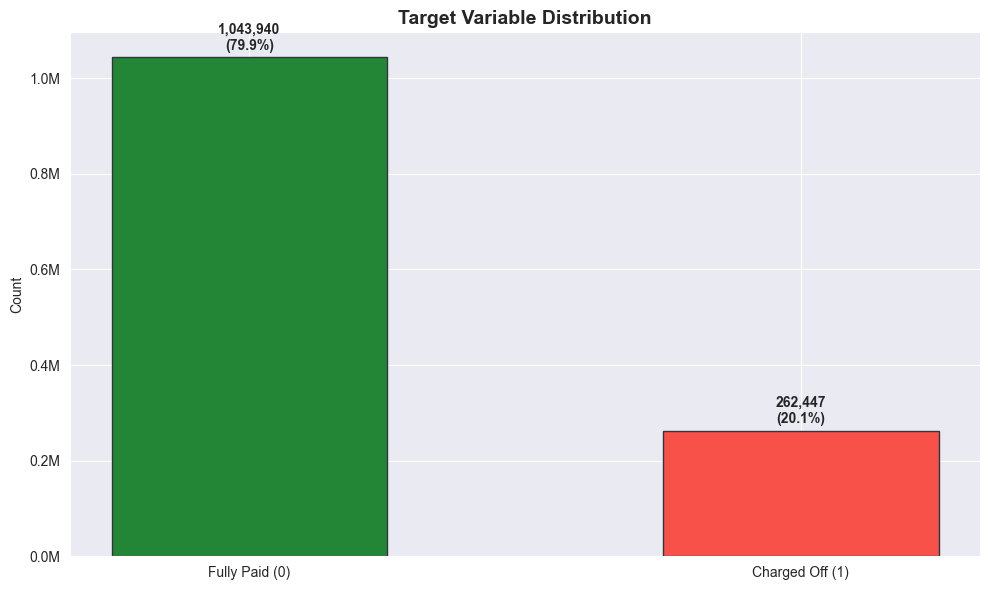

In [29]:
fig, ax = plt.subplots(figsize=(10, 6))
counts = loans['target'].value_counts()
labels = ['Fully Paid (0)', 'Charged Off (1)']
bars = ax.bar(labels, counts.values, width=0.5,
                color=['#238636', '#f85149'], edgecolor='#30363d')

for bar, count in zip(bars, counts.values):
    pct = count / len(loans) * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10000,
            f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom', fontweight='bold')

ax.set_title('Target Variable Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.tight_layout()
plt.show()

About 80% of loans are fully paid and 20% charged off. This imbalance is normal for credit datasets most borrowers do pay back. During modeling I'll use `class_weight='balanced'` and evaluate with PR-AUC rather than accuracy.

### 5.2 Univariate Analysis, Key Numeric Features

I selected six features for their direct relevance to credit risk: loan amount, interest rate, annual income, DTI, revolving utilization, and credit history.

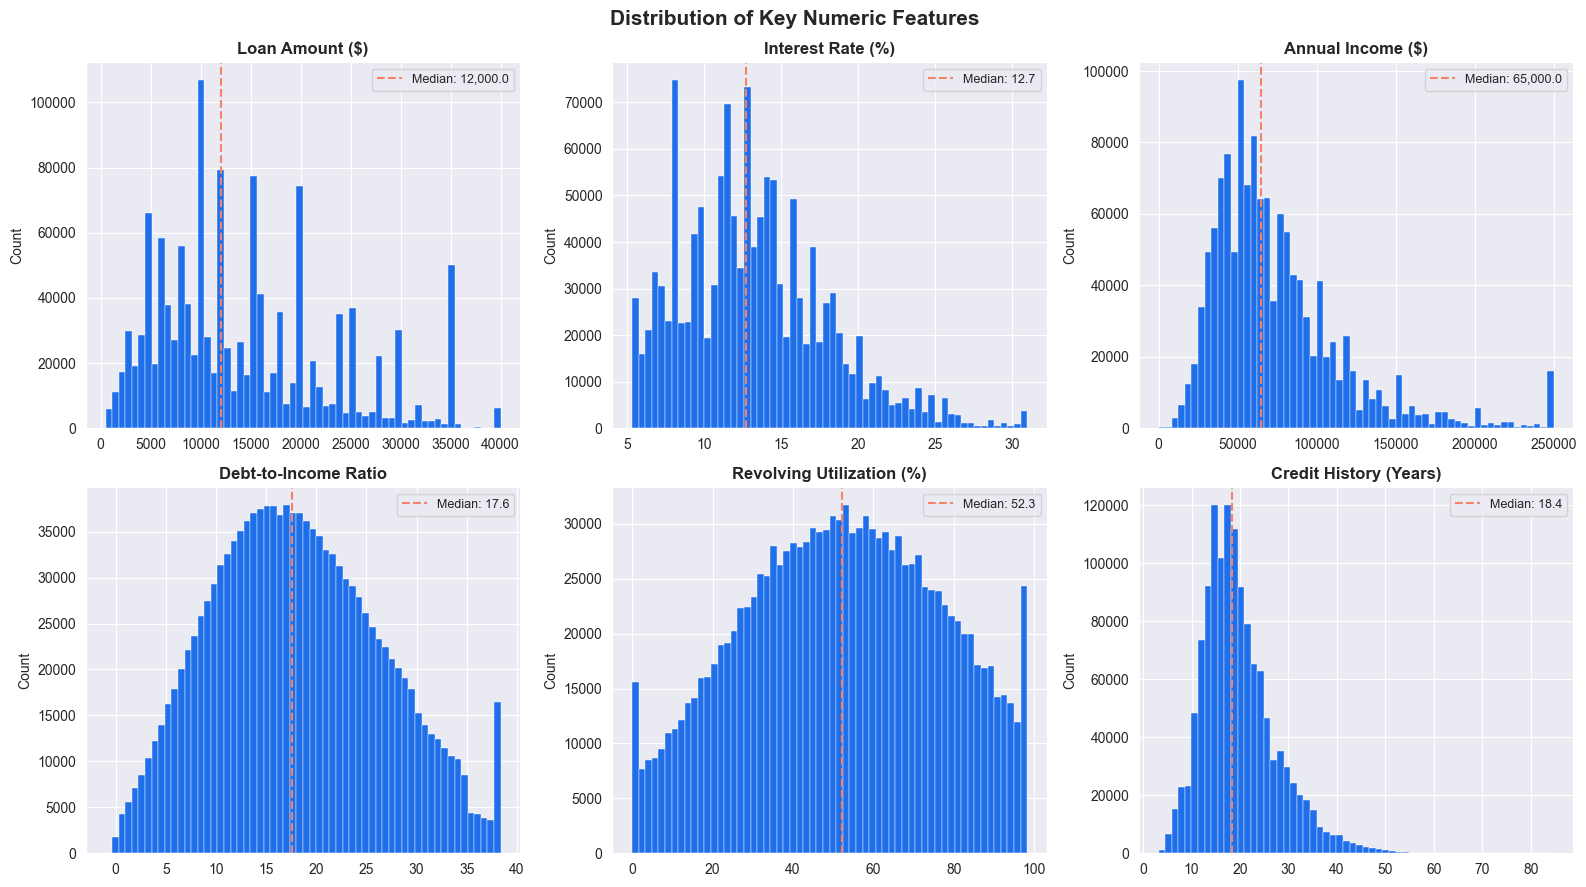

In [30]:
key_features = ['loan_amnt', 'int_rate', 'annual_inc', 'dti',
                   'revol_util', 'credit_history_years']
feature_labels = ['Loan Amount ($)', 'Interest Rate (%)', 'Annual Income ($)',
                  'Debt-to-Income Ratio', 'Revolving Utilization (%)', 'Credit History (Years)']

clip_upper = {
    'annual_inc': loans['annual_inc'].quantile(0.99),
    'dti': loans['dti'].quantile(0.99),
    'revol_util': loans['revol_util'].quantile(0.99)
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, (col, label) in enumerate(zip(key_features, feature_labels)):
    ax = axes[i]
    data = loans[col].clip(upper=clip_upper.get(col, loans[col].max()))

    ax.hist(data, bins=60, color='#1f6feb', edgecolor='white', linewidth=0.3)

    med = loans[col].median()
    ax.axvline(med, color='#f78166', linestyle='--', linewidth=1.5,
               label=f'Median: {med:,.1f}')

    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

plt.suptitle('Distribution of Key Numeric Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

- **Loan amount** is right-skewed with visible spikes at round numbers ($10K, $15K, $20K). Median is $12,000.
- **Interest rate** looks roughly normal, median 12.7%. The spread from 5% to 30% reflects real risk differentiation in LendingClub's grading system.
- **Annual income** is very skewed a few high earners drag the distribution far right. The 99th percentile is used to clip the plot.
- **DTI** is roughly normal with median 17.6. Anything above 30 starts to look risky.
- **Revolving utilization** is spread across the full 0–100% range, median 52.3%. Above 30% is generally a negative signal.
- **Credit history** is also right-skewed, median 18.4 years.

### 5.3 Bivariate Analysis Features vs. Default

How do these distributions differ between borrowers who paid back and those who charged off?

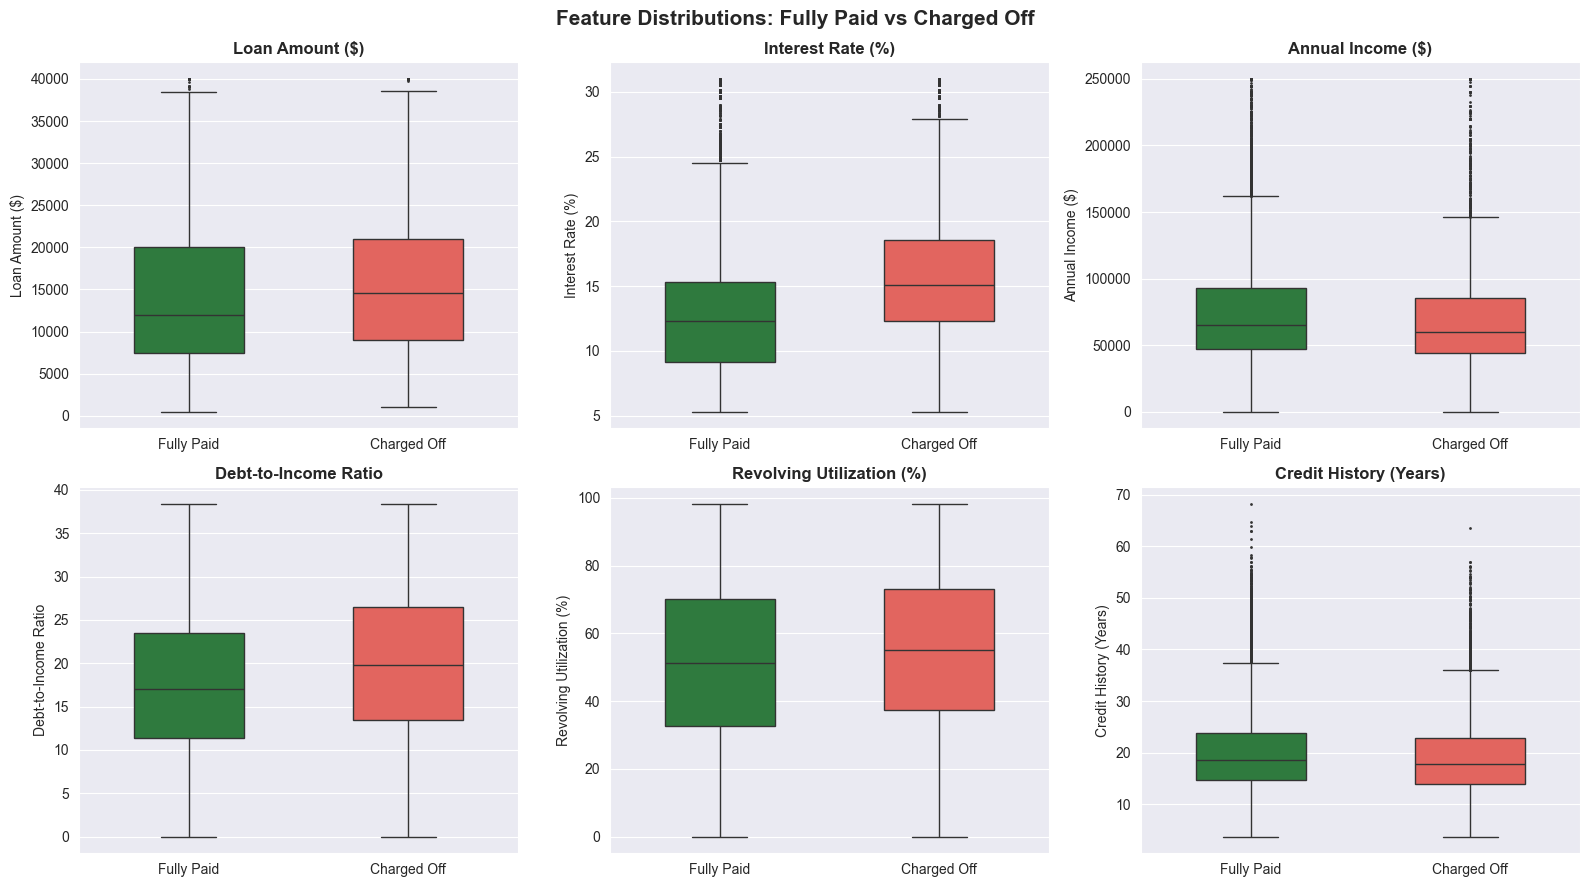

In [31]:
key_features2 = ['loan_amnt', 'int_rate', 'annual_inc', 'dti',
                   'revol_util', 'credit_history_years']
feature_labels = ['Loan Amount ($)', 'Interest Rate (%)', 'Annual Income ($)',
                  'Debt-to-Income Ratio', 'Revolving Utilization (%)', 'Credit History (Years)']

clip_upper = {
    'annual_inc': loans['annual_inc'].quantile(0.99),
    'dti': loans['dti'].quantile(0.99),
    'revol_util': loans['revol_util'].quantile(0.99)
}

sample = loans.sample(n=50000, random_state=SEED)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, (col, label) in enumerate(zip(key_features2, feature_labels)):
    ax = axes[i]
    upper = clip_upper.get(col, sample[col].max())
    plot_data = sample[[col, 'target']].copy()
    plot_data[col] = plot_data[col].clip(upper=upper)
    plot_data['Status'] = plot_data['target'].map({0: 'Fully Paid', 1: 'Charged Off'})

    sns.boxplot(data=plot_data, x='Status', y=col, ax=ax,
                palette={'Fully Paid': '#238636', 'Charged Off': '#f85149'},
                width=0.5, fliersize=1)

    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(label)

plt.suptitle('Feature Distributions: Fully Paid vs Charged Off', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

**Interest rate** is the clearest separator defaulted loans have noticeably higher rates (median ~15% vs ~12%). This makes sense

**DTI** and **revolving utilization** also show visible differences. Borrowers who defaulted were carrying more existing debt and using a larger share of their available revolving credit before taking this loan both signs of financial stress.

**Annual income** and **credit history** show almost no difference. Income matters less than how it's being used, and credit history length doesn't say much about payment behavior on its own.

### 5.4 Categorical Features vs Default Rate

For categorical variables I look at the default rate within each category.

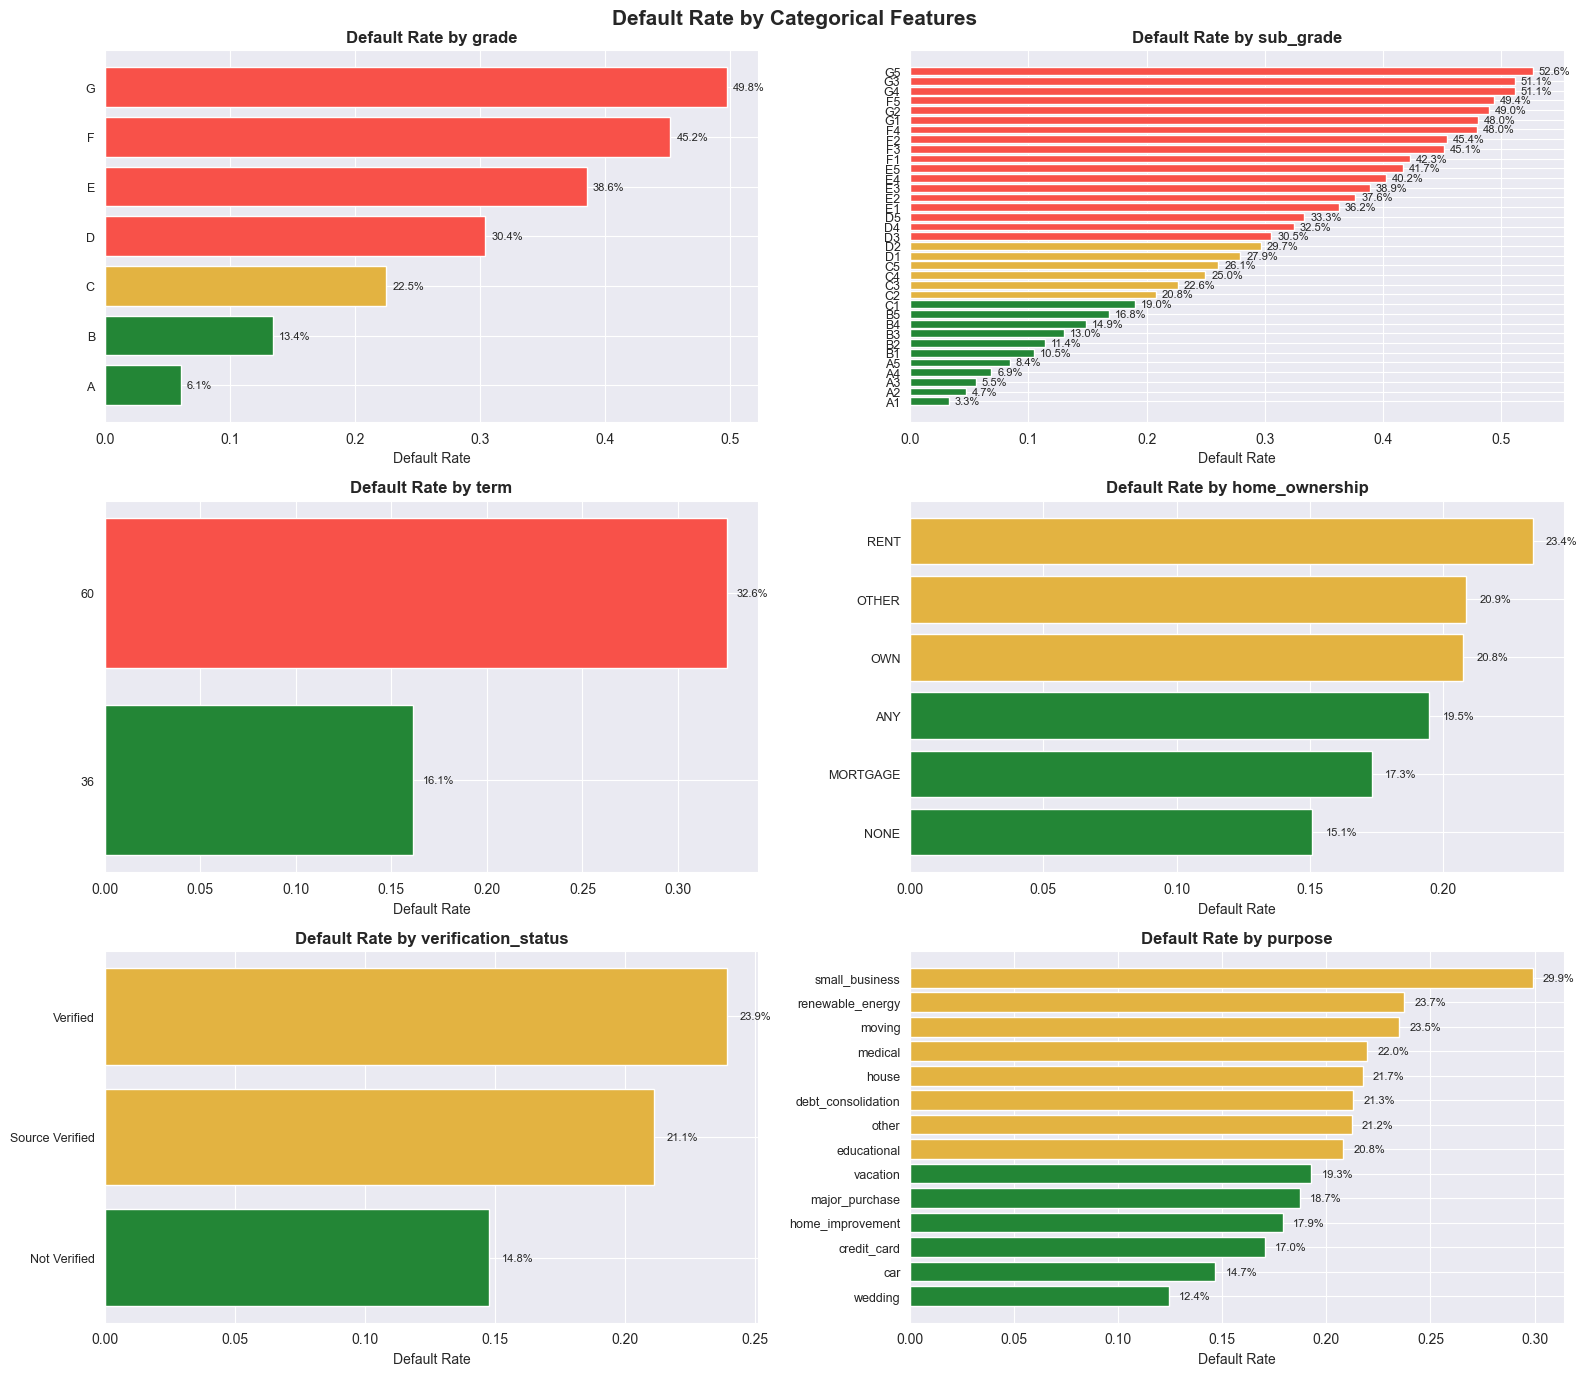

In [32]:
cat_features = ['grade', 'sub_grade', 'term', 'home_ownership',
                'verification_status', 'purpose']

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    ax = axes[i]
    default_rate = loans.groupby(col)['target'].mean().sort_values(ascending=False)
    colors = ['#f85149' if r > 0.3 else '#e3b341' if r > 0.2 else '#238636'
                    for r in default_rate.values]

    bars = ax.barh(range(len(default_rate)), default_rate.values, color=colors)
    ax.set_yticks(range(len(default_rate)))
    ax.set_yticklabels(default_rate.index, fontsize=9)
    ax.set_xlabel('Default Rate')
    ax.set_title(f'Default Rate by {col}', fontsize=12, fontweight='bold')

    for bar, rate in zip(bars, default_rate.values):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
                f'{rate:.1%}', va='center', fontsize=8)
    ax.invert_yaxis()

plt.suptitle('Default Rate by Categorical Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

**Grade** is the most powerful single feature. Default rate rises monotonically from A (6.1%) to G (49%).

**Sub-grade** shows the same pattern at finer granularity, A1 at 3% to G5 at 51%.

**Term** is a strong signal too: 60-month loans default at almost double the rate of 36-month loans. Longer repayment = more time for something to go wrong.

**Verification status** has a counterintuitive result. Verified borrowers default more than Not Verified ones.

**Purpose** shows small business loans as the riskiest (29.8%) and car and wedding loans as the safest (~12%).

### 5.5 Correlation Analysis

I check correlations between numeric features to find redundant pairs and identify which features have the strongest linear relationship with the target.

In [33]:
numeric_cols = loans.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'target']

target_corr = loans[numeric_cols].corrwith(loans['target']).sort_values()

print('Top 10 positively correlated with default:')
for col, val in target_corr.tail(10).items():
    print(f'  {col:35s} {val:+.4f}')

print('\nTop 10 negatively correlated with default:')
for col, val in target_corr.head(10).items():
    print(f'  {col:35s} {val:+.4f}')

Top 10 positively correlated with default:
  bc_util                             +0.0653
  inq_last_6mths                      +0.0656
  percent_bc_gt_75                    +0.0672
  num_rev_tl_bal_gt_0                 +0.0699
  num_actv_rev_tl                     +0.0712
  num_tl_op_past_12m                  +0.0845
  dti                                 +0.0869
  acc_open_past_24mths                +0.0993
  term                                +0.1755
  int_rate                            +0.2582

Top 10 negatively correlated with default:
  bc_open_to_buy                      -0.0791
  avg_cur_bal                         -0.0755
  tot_hi_cred_lim                     -0.0749
  mort_acc                            -0.0729
  total_bc_limit                      -0.0697
  tot_cur_bal                         -0.0675
  mo_sin_rcnt_tl                      -0.0523
  mo_sin_rcnt_rev_tl_op               -0.0510
  total_rev_hi_lim                    -0.0499
  mths_since_recent_bc                -

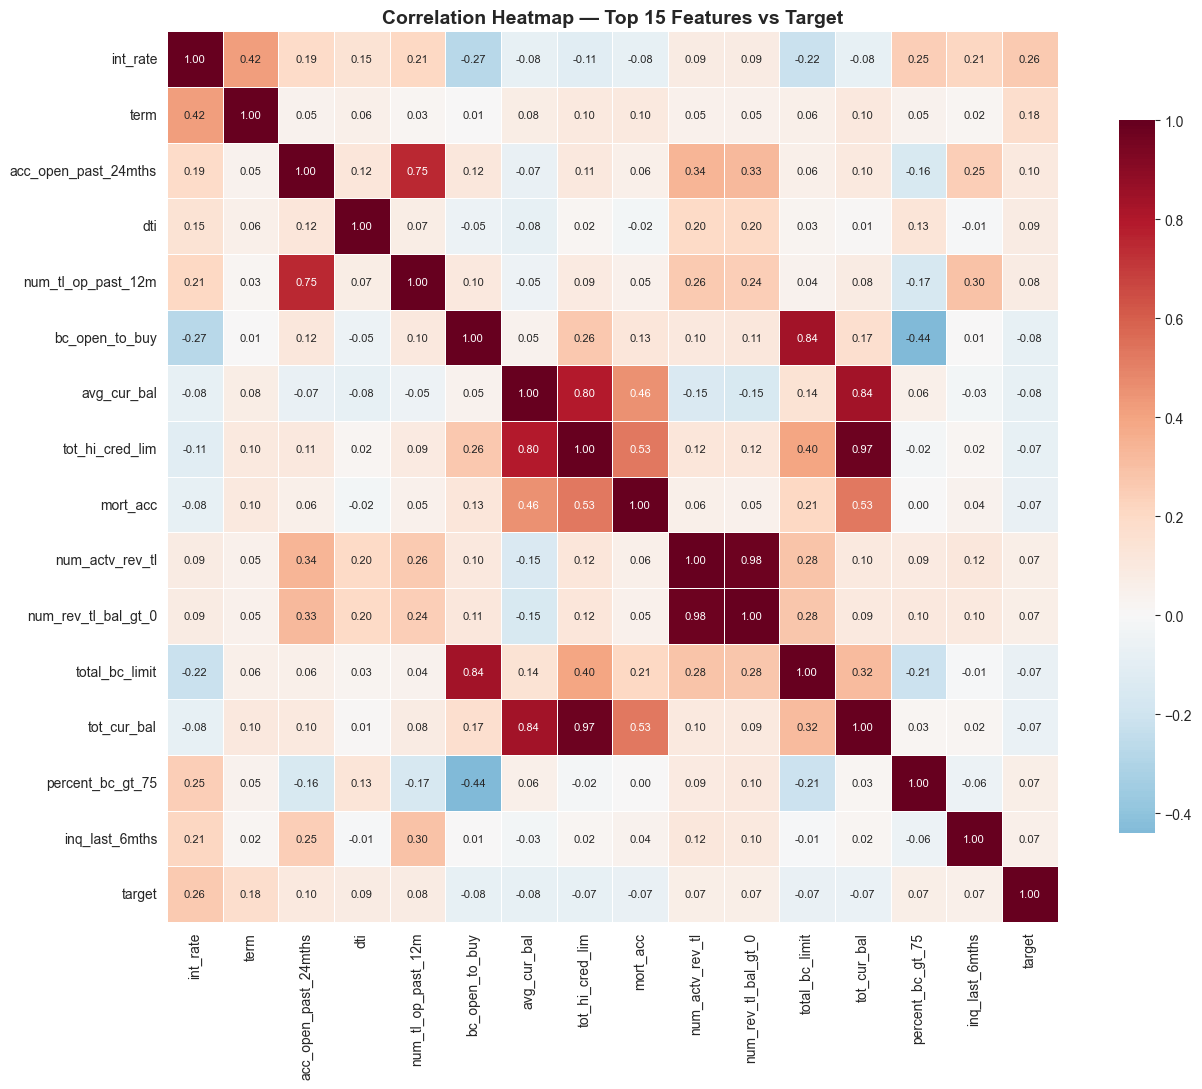

In [34]:
top_features = (target_corr.abs()
                .sort_values(ascending=False)
                .head(15)
                .index.tolist())

corr_matrix = loans[top_features + ['target']].corr()

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax,
            annot_kws={'fontsize': 8},
            cbar_kws={'shrink': 0.8})

ax.set_title('Correlation Heatmap — Top 15 Features vs Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

`int_rate` has the strongest correlation with default at +0.26, consistent with everything seen so far. `term` is second at +0.18.

The heatmap also reveals several near-duplicate feature pairs that need to be addressed before modeling:
- `num_actv_rev_tl` and `num_rev_tl_bal_gt_0` at 0.98 essentially measuring the same thing
- `avg_cur_bal`, `tot_hi_cred_lim`, `tot_cur_bal` correlated at 0.80–0.97 all measure total balance/limits
- `acc_open_past_24mths` and `num_tl_op_past_12m` at 0.75

Keeping both columns from a near-duplicate pair adds noise without new information and can destabilise linear models. These will be removed in Section 6.

## 6. Feature Engineering & Preprocessing Pipeline <a id="6-feature-engineering"></a>

The preprocessing up to this point was done directly on the `loans` DataFrame. From this section onwards everything runs inside a scikit-learn Pipeline. The core reason is leakage prevention: imputation medians, scaler statistics, and category frequencies all have to be learned from the training set only. Doing any of this on the full dataset before splitting contaminates the test set with information it shouldn't have.

I also take the opportunity to remove multicollinear features and engineer a few ratio features that the raw columns don't express.

### 6.1 Remove Multicollinear Features

From the correlation heatmap, I drop the weaker column from each redundant pair. "Weaker" means lower absolute correlation with the target.

In [35]:
drop_multicollinear = [
    'num_tl_op_past_12m',    # r=0.75 with acc_open_past_24mths — 24-month window kept
    'tot_cur_bal',           # r=0.97 with avg_cur_bal
    'tot_hi_cred_lim',       # r=0.80 with avg_cur_bal
    'num_rev_tl_bal_gt_0',   # r=0.98 with num_actv_rev_tl
    'total_bc_limit',        # r=0.64 with bc_open_to_buy
    'funded_amnt',           # r≈1.0 with loan_amnt
    'funded_amnt_inv',       # r≈1.0 with loan_amnt
    'grade',                 # sub_grade contains all grade info at finer granularity
]

drop_multicollinear = [c for c in drop_multicollinear if c in loans.columns]
loans.drop(columns=drop_multicollinear, inplace=True)

print(f'Dropped {len(drop_multicollinear)} columns.')
print(f'Shape: {loans.shape}')

Dropped 8 columns.
Shape: (1306387, 61)


### 6.2 Train / Test Split

The dataset is split before any feature engineering or encoding. Every step that follows imputation statistics, scaler parameters, rare-category thresholds will be fit on `X_train` only, then applied to `X_test`. Fitting on the full dataset before splitting is data leakage.

`stratify=y` preserves the original class ratio in both sets.

In [36]:
X = loans.drop(columns=['target'])
y = loans['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.20,
    random_state = SEED,
    stratify = y
)

print('Split sizes:')
print(f'  X_train : {X_train.shape[0]:>10,} rows × {X_train.shape[1]} columns')
print(f'  X_test  : {X_test.shape[0]:>10,} rows × {X_test.shape[1]} columns')
print()

train_rate = y_train.mean()
test_rate = y_test.mean()
drift = abs(train_rate - test_rate)

print(f'Train default rate : {train_rate:.4f}')
print(f'Test  default rate : {test_rate:.4f}')
print(f'Drift : {drift:.6f}  [{"OK" if drift < 0.001 else "WARNING"}]')

Split sizes:
  X_train :  1,045,109 rows × 60 columns
  X_test  :    261,278 rows × 60 columns

Train default rate : 0.2009
Test  default rate : 0.2009
Drift : 0.000002  [OK]


### 6.3 Custom Sklearn Transformers

I write three custom transformers for domain-specific logic that standard sklearn components can't handle. Each inherits from `BaseEstimator` and `TransformerMixin`, which makes them drop-in compatible with `Pipeline` and `GridSearchCV`.

In [37]:
class RatioFeatureEngineer(BaseEstimator, TransformerMixin):
    """
    Creates five financial ratio features.

    Ratios normalise for scale — a $500 monthly payment is very different
    for someone earning $2,000/month vs $15,000/month. Raw values miss this.
    """

    def fit(self, X, y=None):
        return self     # nothing to learn from data

    def transform(self, X):
        X = X.copy()    # never modify the original in-place

        monthly_inc = X['annual_inc'] / 12

        X['installment_to_income'] = X['installment'] / monthly_inc.replace(0, np.nan)
        X['loan_to_income'] = X['loan_amnt'] / X['annual_inc'].replace(0, np.nan)
        X['open_acc_ratio'] = X['open_acc'] / X['total_acc'].replace(0, np.nan)
        X['revol_bal_to_income'] = X['revol_bal'] / X['annual_inc'].replace(0, np.nan)

        # Interaction: borrower under stress from BOTH high rate AND high existing debt
        X['int_rate_x_dti'] = X['int_rate'] * X['dti']

        X.replace([np.inf, -np.inf], np.nan, inplace=True)
        return X


class SubGradeOrdinalEncoder(BaseEstimator, TransformerMixin):
    """
    Encodes sub_grade (A1–G5) as an ordered integer (0–34).

    The sub-grade has a known risk ordering: A1 is the safest borrower,
    G5 the riskiest. Encoding as an integer preserves this monotonic
    relationship — one-hot encoding would destroy it.
    """

    SUB_GRADE_ORDER = [
        'A1','A2','A3','A4','A5',
        'B1','B2','B3','B4','B5',
        'C1','C2','C3','C4','C5',
        'D1','D2','D3','D4','D5',
        'E1','E2','E3','E4','E5',
        'F1','F2','F3','F4','F5',
        'G1','G2','G3','G4','G5',
    ]
    _GRADE_MAP = {g: i for i, g in enumerate(SUB_GRADE_ORDER)}

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X['sub_grade'] = (
            X['sub_grade']
            .astype(str)
            .map(self._GRADE_MAP)   # A1→0, A2→1, …, G5→34
            .fillna(-1)             # unknown category → -1
            .astype(int)
        )
        return X


class RareCategoryGrouper(BaseEstimator, TransformerMixin):
    """
    Replaces infrequent category labels with 'other'.

    The frequency threshold is learned from the training set only.
    Categories that are rare in training get grouped in the test set
    using training frequencies — this prevents leakage and ensures the
    model never encounters a one-hot column it wasn't trained on.

    Parameters
    ----------
    cols      : list[str] — columns to apply grouping to
    threshold : float     — minimum relative frequency to keep a label (default 0.01)
    """

    def __init__(self, cols, threshold=0.01):
        self.cols = cols
        self.threshold = threshold

    def fit(self, X, y=None):
        self.frequent_categories_ = {}
        for col in self.cols:
            if col not in X.columns:
                continue
            freq = X[col].astype(str).value_counts(normalize=True)
            self.frequent_categories_[col] = set(freq[freq >= self.threshold].index)
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.cols:
            if col not in X.columns:
                continue
            frequent = self.frequent_categories_.get(col, set())
            X[col] = X[col].astype(str).apply(
                lambda v: v if v in frequent else 'other'
            )
        return X


print('Transformers defined:')
print(f'  RatioFeatureEngineer: {RatioFeatureEngineer()}')
print(f'  SubGradeOrdinalEncoder: {SubGradeOrdinalEncoder()}')
print(f'  RareCategoryGrouper: {RareCategoryGrouper(cols=["purpose", "home_ownership", "addr_state"])}')
print()
print(f'  Sub-grade mapping: {len(SubGradeOrdinalEncoder._GRADE_MAP)} entries')
print(f'  A1 → {SubGradeOrdinalEncoder._GRADE_MAP["A1"]}   (safest)')
print(f'  G5 → {SubGradeOrdinalEncoder._GRADE_MAP["G5"]}  (riskiest)')

Transformers defined:
  RatioFeatureEngineer: RatioFeatureEngineer()
  SubGradeOrdinalEncoder: SubGradeOrdinalEncoder()
  RareCategoryGrouper: RareCategoryGrouper(cols=['purpose', 'home_ownership', 'addr_state'])

  Sub-grade mapping: 35 entries
  A1 → 0   (safest)
  G5 → 34  (riskiest)


All three transformers are defined. The `SubGradeOrdinalEncoder` covers all 35 categories. The `RareCategoryGrouper` includes `addr_state` 51 states is too many columns to one-hot encode naively, and several states have very few loans. States below 1% frequency in training will be grouped into `'other'`. Importantly, this grouping learns from `X_train` only the old approach of computing state default rates on the full dataset was target leakage and has been replaced.

### 6.4 Build the Preprocessing Pipeline

The `ColumnTransformer` applies the correct transformation chain to each column group in parallel:

- **Numeric** median imputation, then StandardScaler. Required for Logistic Regression.
- **`sub_grade`** already integer-encoded; just impute and scale for consistency.
- **Nominal categorical** group rare categories (fit on train only), then one-hot encode.

In [38]:
# Apply the custom transformers first — they add new columns that ColumnTransformer needs to know about
ratio_engineer = RatioFeatureEngineer()
grade_encoder = SubGradeOrdinalEncoder()

X_train_fe = grade_encoder.fit_transform(ratio_engineer.fit_transform(X_train))
X_test_fe = grade_encoder.transform(ratio_engineer.transform(X_test))

print('After custom transformers:')
print(f'  X_train_fe: {X_train_fe.shape}')
print(f'  X_test_fe:  {X_test_fe.shape}')
print()
print('New ratio columns:')
print([c for c in X_train_fe.columns if c not in X_train.columns])

After custom transformers:
  X_train_fe: (1045109, 65)
  X_test_fe:  (261278, 65)

New ratio columns:
['installment_to_income', 'loan_to_income', 'open_acc_ratio', 'revol_bal_to_income', 'int_rate_x_dti']


In [39]:
# application_type: Individual=0, Joint App=1 — simple binary encoding
X_train_fe['application_type'] = (X_train_fe['application_type'].astype(str) == 'Joint App').astype(int)
X_test_fe['application_type'] = (X_test_fe['application_type'].astype(str)  == 'Joint App').astype(int)

# Define column groups
rare_group_cols = ['home_ownership', 'verification_status', 'purpose', 'addr_state']
ordinal_cols = ['sub_grade']
numeric_cols_pipe = [c for c in X_train_fe.select_dtypes(include=[np.number]).columns
                     if c not in ordinal_cols]

print(f'Numeric columns : {len(numeric_cols_pipe)}')
print(f'Ordinal columns : {ordinal_cols}')
print(f'Categorical cols : {rare_group_cols}')

Numeric columns : 60
Ordinal columns : ['sub_grade']
Categorical cols : ['home_ownership', 'verification_status', 'purpose', 'addr_state']


In [40]:
# Numeric pipeline: impute → scale
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

# Categorical pipeline: group rare → one-hot
categorical_pipeline = Pipeline(steps=[
    ('rare_grouper', RareCategoryGrouper(cols=rare_group_cols, threshold=0.01)),
    ('onehot',       OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

# ColumnTransformer — runs all three in parallel
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline,      numeric_cols_pipe),
        ('ord', numeric_pipeline,      ordinal_cols),
        ('cat', categorical_pipeline,  rare_group_cols),
    ],
    remainder='drop'
)

print(preprocessor)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['loan_amnt', 'term', 'int_rate',
                                  'installment', 'emp_length', 'annual_inc',
                                  'dti', 'delinq_2yrs', 'inq_last_6mths',
                                  'open_acc', 'pub_rec', 'revol_bal',
                                  'revol_util', 'total_acc',
                                  'collections_12_mths_ex_med',
                                  'application_type', 'acc_n...
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                             

In [41]:
# Fit on training data only — transform both sets
X_train_processed = preprocessor.fit_transform(X_train_fe)
X_test_processed  = preprocessor.transform(X_test_fe)

print(f'X_train_processed : {X_train_processed.shape}')
print(f'X_test_processed  : {X_test_processed.shape}')
print()
print(f'NaNs in train: {np.isnan(X_train_processed).sum()}')
print(f'NaNs in test:  {np.isnan(X_test_processed).sum()}')

X_train_processed : (1045109, 105)
X_test_processed  : (261278, 105)

NaNs in train: 0
NaNs in test:  0


### 6.5 Feature Engineering Summary

| Group | Columns | Steps |
|---|---|---|
| Numeric | ~55 columns + 5 ratio features | Median imputation → StandardScaler |
| Ordinal | `sub_grade` | Median imputation → StandardScaler |
| Categorical | `home_ownership`, `verification_status`, `purpose`, `addr_state` | RareCategoryGrouper (1%) → OneHotEncoder |

All preprocessing is fit on `X_train` only. The `addr_state` encoding uses no target information — categories are grouped by frequency in training, not by default rate. The dataset is now fully numeric with zero missing values and no leakage.

## 7. Mathematical Framework <a id="7-mathematical-framework"></a>

Before building models, I describe the mathematical foundations behind each algorithm how they learn and why they are appropriate for this classification problem.

### 7.1 Logistic Regression

Logistic Regression is the natural starting point for binary classification. Despite the name it is a classification model, not a regression one. The idea is to model the probability that a loan defaults given its features.

**The sigmoid function**

The raw linear combination $\mathbf{w}^T \mathbf{x} + b$ can produce any value on the real line, but a probability must be between 0 and 1. The sigmoid function squashes it into that range:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

So the predicted probability of default is:

$$\hat{p} = \sigma(\mathbf{w}^T \mathbf{x} + b) = \frac{1}{1 + e^{-(\mathbf{w}^T \mathbf{x} + b)}}$$

**Loss function - Binary Cross-Entropy**

The model is trained by minimizing the average log-loss over all training examples:

$$\mathcal{L}(\mathbf{w}) = -\frac{1}{n} \sum_{i=1}^{n} \left[ y_i \log(\hat{p}_i) + (1 - y_i) \log(1 - \hat{p}_i) \right]$$

Where:
- $y_i \in \{0, 1\}$ - true label for loan $i$
- $\hat{p}_i$ - model's predicted default probability for loan $i$
- $n$ - number of training examples

When $y_i = 1$ (default), the loss penalizes the model for assigning a low $\hat{p}_i$. When $y_i = 0$, it penalizes a high $\hat{p}_i$. The logarithm makes this penalty grow very large as the prediction approaches the wrong extreme.

**Regularization**

To prevent overfitting, an L2 penalty is added to the loss:

$$\mathcal{L}_{reg}(\mathbf{w}) = \mathcal{L}(\mathbf{w}) + \frac{1}{2C} \|\mathbf{w}\|^2$$

Where $C$ is the inverse regularization strength. Small $C$ = strong regularization, forces weights toward zero. Large $C$ = weak regularization, allows weights to grow. Sklearn's default is $C = 1.0$.

**Why it's suitable here:** Logistic Regression is interpretable each weight $w_j$ tells you the change in log-odds of default for a one-unit increase in feature $j$, holding everything else constant. It also requires scaled features, which is why `StandardScaler` is part of the pipeline. Its main limitation is that it can only learn linear decision boundaries, so it will likely underfit the complex interactions in this dataset.

### 7.2 Decision Tree

A Decision Tree partitions the feature space into rectangular regions by applying a series of binary splits. Each internal node tests a single feature against a threshold; each leaf node assigns a class label (or probability).

**Splitting criterion - Gini Impurity**

At each node, the algorithm searches for the feature $j$ and threshold $t$ that produce the purest possible child nodes. Purity is measured by Gini impurity:

$$G(S) = 1 - \sum_{k=0}^{1} p_k^2$$

Where $p_k$ is the fraction of examples in set $S$ belonging to class $k$. A pure node (all one class) has $G = 0$. A perfectly mixed node has $G = 0.5$.

The split that minimizes the weighted Gini impurity of the two child nodes is chosen:

$$\Delta G = G(S) - \frac{|S_L|}{|S|} G(S_L) - \frac{|S_R|}{|S|} G(S_R)$$

Where $S_L$ and $S_R$ are the left and right child sets.

**Prediction**

For a new sample, the tree traverses the learned splits from root to leaf. The leaf's class probability is the fraction of training samples in that leaf that belonged to each class.

**Why it's suitable here:** Trees naturally handle non-linear relationships and feature interactions without any scaling. They are also interpretable you can visualize the tree and follow the path for any prediction. The main weakness is variance: a fully grown tree memorizes the training data. `max_depth` and `min_samples_leaf` are the key hyperparameters for controlling this.

### 7.3 Random Forest

Random Forest is an ensemble method that builds many decision trees and combines their predictions. Two sources of randomness prevent the trees from being identical copies of each other:

**1. Bootstrap sampling (Bagging)**

Each tree is trained on a bootstrap sample, a random sample of $n$ training examples drawn *with replacement*. On average, about 63.2% of the original training examples appear in any given bootstrap sample; the remaining ~36.8% are "out-of-bag" (OOB) and can be used for validation without a separate split.

**2. Feature subsampling**

At each split, only a random subset of $\sqrt{p}$ features (where $p$ is the total number of features) is considered as candidates. This decorrelates the trees, if one feature is very strong, it won't dominate every tree.

**Aggregation**

For classification, the final prediction is the majority vote across all $T$ trees:

$$\hat{y} = \text{mode}\left(\hat{y}_1, \hat{y}_2, \ldots, \hat{y}_T\right)$$

For probability estimates (which is what we need for PR-AUC), the predicted probability is the average of individual tree probabilities:

$$\hat{p} = \frac{1}{T} \sum_{t=1}^{T} \hat{p}_t$$

**Why variance is reduced**

Each individual tree has high variance, small changes in training data produce very different trees. But averaging many uncorrelated trees reduces variance without increasing bias, by the law of large numbers. This is the core idea of bagging.

**Why it's suitable here:** Random Forest handles the non-linearities and feature interactions in credit data well. It is robust to outliers and does not require feature scaling. It also provides feature importance estimates (mean decrease in Gini impurity), which will be useful for interpretation. The main cost is that it is less interpretable than a single tree and significantly slower to train.

### 7.4 Gradient Boosting

Gradient Boosting builds an ensemble sequentially rather than in parallel. Each new tree corrects the errors of the previous ensemble. The approach is to frame the problem as gradient descent in function space.

**The ensemble prediction**

The model is a sum of $M$ weak learners (shallow trees):

$$F_M(\mathbf{x}) = F_0 + \sum_{m=1}^{M} \eta \cdot h_m(\mathbf{x})$$

Where:
- $F_0$: initial prediction (usually log-odds of the mean)
- $h_m$: the $m$-th tree
- $\eta$: learning rate (shrinkage), typically 0.01–0.3

**How each tree is fitted**

At each step $m$, the algorithm computes the *pseudo-residual* the negative gradient of the loss function with respect to the current prediction:

$$r_{im} = -\left[\frac{\partial \mathcal{L}(y_i, F(\mathbf{x}_i))}{\partial F(\mathbf{x}_i)}\right]_{F = F_{m-1}}$$

For log-loss this simplifies to:

$$r_{im} = y_i - \hat{p}_{m-1}(\mathbf{x}_i)$$

Which is just the residual how wrong the current model is for each example. The new tree $h_m$ is fitted to these residuals. The tree learns where the ensemble is currently making the biggest mistakes and corrects in that direction.

**Learning rate and the bias-variance tradeoff**

A small learning rate $\eta$ means each tree contributes only a small correction. This requires more trees to reach the same training error, but the model generalizes better. A large $\eta$ trains faster but is more likely to overfit. The standard recommendation is to use a small $\eta$ (0.05–0.1) with early stopping.

**Why it's suitable here:** Gradient Boosting consistently achieves the best performance on structured tabular data with mixed feature types which is exactly what this dataset is. It handles the class imbalance through the loss function directly. The main downside is training time and the number of hyperparameters to tune (`n_estimators`, `max_depth`, `learning_rate`, `subsample`).

### 7.5 Evaluation Metrics

Accuracy is not a useful metric when classes are imbalanced. A model that predicts "Fully Paid" for every loan would be 80% accurate while being completely useless. Three metrics are used instead:

**ROC-AUC**

The ROC curve plots the True Positive Rate (Recall) against the False Positive Rate at every possible classification threshold. The area under this curve (AUC) measures the model's ability to rank a random defaulter above a random non-defaulter:

$$\text{ROC-AUC} = P(\hat{p}_{default} > \hat{p}_{non-default})$$

A random classifier scores 0.5; a perfect classifier scores 1.0. ROC-AUC is threshold-independent and is a standard benchmark, but it can be optimistic on imbalanced datasets because it includes the large true-negative population.

**PR-AUC (Precision-Recall AUC)**

The PR curve plots Precision against Recall at every threshold:

$$\text{Precision} = \frac{TP}{TP + FP} \qquad \text{Recall} = \frac{TP}{TP + FN}$$

PR-AUC is more informative than ROC-AUC when the positive class (default) is rare, because it focuses only on how well the model identifies the minority class. This is the primary evaluation metric for this project.

**F1 Score**

The harmonic mean of Precision and Recall at a specific threshold:

$$F_1 = 2 \cdot \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

Used for a single-threshold summary comparison between models.

**Business interpretation**

In credit risk, these metrics translate directly to money:
- **False Negative** (missed default) = loan is approved, borrower defaults, capital is lost
- **False Positive** (good borrower rejected) = lost interest income, lost customer

The relative cost of these two errors determines the optimal classification threshold. This is explored in Section 11.

## 8. Baseline Models <a id="8-baseline-models"></a>

Baseline model is trained before anything more complex. The goal is not peak performance it is to establish a reference point. If a more advanced model can't meaningfully beat Logistic Regression, that tells me something important about the data.

All models are evaluated on `X_test_processed`, which nothing has seen during training.

In [42]:
log_regression = LogisticRegression(
    C= 1.0,
    class_weight= 'balanced',
    max_iter= 1000,
    solver= 'lbfgs',
    random_state= SEED
)

In [43]:
log_regression.fit(X_train_processed, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [44]:
# Predictions and Probabilities on the held-out test set
y_pred_log = log_regression.predict(X_test_processed)
y_prob_log = log_regression.predict_proba(X_test_processed)[:, 1]
print("=== Logistic Regression ===")
print()
print(classification_report(y_test, y_pred_log, target_names=['Fully Paid', 'Charged Off']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_log):.4f}")
print(f"PR-AUC: {average_precision_score(y_test, y_prob_log):.4f}")

=== Logistic Regression ===

              precision    recall  f1-score   support

  Fully Paid       0.88      0.67      0.76    208788
 Charged Off       0.33      0.65      0.44     52490

    accuracy                           0.66    261278
   macro avg       0.61      0.66      0.60    261278
weighted avg       0.77      0.66      0.69    261278

ROC-AUC: 0.7180
PR-AUC: 0.3813


Logistic Regression gives ROC-AUC 0.718 and PR-AUC 0.381. For a linear model on a dataset with this many non-linear interactions, that is a reasonable result but not a good one.

Recall for Charged Off is 0.65, the model catches 65% of actual defaults. Precision is only 0.33 though of everything the model flags as default, only 1 in 3 is an actual default. `class_weight='balanced'` pushes the model toward finding defaults, but since the decision boundary is linear it cannot separate the classes cleanly and produces a large number of false positives.

The 0.66 accuracy looks worse than the majority class baseline (80%), which is expected with balanced weights the model traded accuracy and precision for higher default recall.

These numbers are the reference point. Every subsequent model needs to beat them, especially PR-AUC.

### 8.2 Decision Tree

Unlike Logistic Regression, a Decision Tree can capture non-linear relationships and feature interactions without any scaling. I limit the depth to 8 levels deep enough to capture real structure, shallow enough to avoid memorizing the training data.

In [45]:
dt = DecisionTreeClassifier(
    max_depth= 8,
    min_samples_leaf= 200,
    class_weight= 'balanced',
    random_state= SEED
)

In [46]:
dt.fit(X_train_processed, y_train)
y_pred_dt = dt.predict(X_test_processed)
y_prob_dt = dt.predict_proba(X_test_processed)[:, 1]

In [47]:
print("=== Decision Tree (max_depth=8) ===")
print()
print(classification_report(y_test, y_pred_dt, target_names=['Fully Paid', 'Charged Off']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_dt):.4f}")
print(f"PR-AUC: {average_precision_score(y_test, y_prob_dt):.4f}")

=== Decision Tree (max_depth=8) ===

              precision    recall  f1-score   support

  Fully Paid       0.88      0.64      0.74    208788
 Charged Off       0.31      0.66      0.42     52490

    accuracy                           0.64    261278
   macro avg       0.60      0.65      0.58    261278
weighted avg       0.77      0.64      0.68    261278

ROC-AUC: 0.7049
PR-AUC: 0.3664


Decision Tree scores ROC-AUC 0.705 and PR-AUC 0.366 both slightly below Logistic Regression. This is somewhat unexpected.

The recall and precision profile looks almost identical to Logistic Regression: high recall (0.66) at the cost of very low precision (0.31). The tree is splitting aggressively to find defaults but is still generating too many false positives.

Two things are worth noting. First, a single tree is inherently unstable small changes in the data produce very different splits, which hurts generalization. Second, `max_depth=8` with `min_samples_leaf=200` may be too constrained for a dataset this wide. The tree doesn't have enough flexibility to find the right combinations of features.


## 9. Advanced Models and Hyperparameter Tuning <a id="9-advanced-models-and-hyperparameter-tuning"></a>

Both ensemble methods here build on decision trees but solve the weaknesses of a single tree in different ways. Random Forest reduces variance by averaging many decorrelated trees trained in parallel. Gradient Boosting reduces bias by building trees sequentially, each one correcting the errors of the previous ensemble.

I train both with sensible starting parameters first, compare them, then run `RandomizedSearchCV` on the stronger candidate.

### 9.1 Random Forest

Starting with 500 trees and a maximum depth of 15. `class_weight='balanced_subsample'` applies the balancing per bootstrap sample rather than globally this is the correct variant for Random Forest because each tree sees a different bootstrap sample.

In [48]:
rf = RandomForestClassifier(
    n_estimators= 500,
    max_depth= 15,
    min_samples_leaf= 50,
    max_features= 'sqrt',
    class_weight= 'balanced',
    n_jobs= -1,
    random_state= SEED
)

In [49]:
rf.fit(X_train_processed, y_train)

,n_estimators,500
,criterion,'gini'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,50
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [50]:
y_pred_rf = rf.predict(X_test_processed)
y_prob_rf = rf.predict_proba(X_test_processed)[:, 1]

In [51]:
print("=== Random Forest (n_estimators=500, max_depth=15) ===")
print()
print(classification_report(y_test, y_pred_rf, target_names=['Fully Paid', 'Charged Off']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")
print(f"PR-AUC: {average_precision_score(y_test, y_prob_rf):.4f}")

=== Random Forest (n_estimators=500, max_depth=15) ===

              precision    recall  f1-score   support

  Fully Paid       0.88      0.68      0.77    208788
 Charged Off       0.33      0.64      0.44     52490

    accuracy                           0.67    261278
   macro avg       0.61      0.66      0.60    261278
weighted avg       0.77      0.67      0.70    261278

ROC-AUC: 0.7194
PR-AUC: 0.3888


### 9.2 Gradient Boosting

`HistGradientBoostingClassifier` uses the same sequential boosting logic described in Section 7.4, but bins continuous features into histograms before splitting. This reduces the number of split candidates from O(n) to O(256), making it 10–20x faster than the standard implementation on large datasets and is the approach used by LightGBM and XGBoost under the hood.

It natively supports class imbalance through the `class_weight` parameter, so no manual sample weighting is needed.

In [52]:
hgb = HistGradientBoostingClassifier(
    max_iter= 300,
    max_depth= 4,
    learning_rate= 0.05,
    min_samples_leaf= 50,
    class_weight= 'balanced',
    random_state= SEED
)

In [53]:
hgb.fit(X_train_processed, y_train)


,loss,'log_loss'
,learning_rate,0.05
,max_iter,300
,max_leaf_nodes,31
,max_depth,4
,min_samples_leaf,50
,l2_regularization,0.0
,max_features,1.0
,max_bins,255
,categorical_features,'from_dtype'
,monotonic_cst,None


In [54]:
y_pred_hgb = hgb.predict(X_test_processed)
y_prob_hgb = hgb.predict_proba(X_test_processed)[:, 1]

print("=== HistGradientBoosting (max_iter=300, depth=4, lr=0.05) ===")
print()
print(classification_report(y_test, y_pred_hgb, target_names=['Fully Paid', 'Charged Off']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_hgb):.4f}")
print(f"PR-AUC: {average_precision_score(y_test, y_prob_hgb):.4f}")

=== HistGradientBoosting (max_iter=300, depth=4, lr=0.05) ===

              precision    recall  f1-score   support

  Fully Paid       0.89      0.65      0.75    208788
 Charged Off       0.33      0.68      0.44     52490

    accuracy                           0.65    261278
   macro avg       0.61      0.66      0.59    261278
weighted avg       0.78      0.65      0.69    261278

ROC-AUC: 0.7257
PR-AUC: 0.3990


HistGradientBoosting gives ROC-AUC 0.726 and PR-AUC 0.399, the best results so far on both metrics. PR-AUC crosses 0.39 for the first time, and recall on defaults reaches 0.68, also the highest of any model so far.

The improvement over Random Forest is small but consistent across every metric, which is the expected pattern. Boosting reduces bias by correcting errors sequentially, while Random Forest reduces variance by averaging. On this dataset, where the main difficulty is finding a clean decision boundary rather than overfitting, bias reduction is more valuable.

This is the model to tune.

In [55]:
# Search space
param_dist = {
    'max_iter': randint(200, 500),
    'max_depth': randint(3, 7),
    'learning_rate': uniform(0.02, 0.13),
    'min_samples_leaf': randint(20, 150)
}



In [56]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

search = RandomizedSearchCV(
    estimator= HistGradientBoostingClassifier(
        class_weight='balanced',
        random_state= SEED
    ),

    param_distributions = param_dist,
    n_iter= 20,
    scoring = 'average_precision',
    cv = cv,
    n_jobs= -1,
    verbose= 1,
    random_state= SEED

)


In [57]:
search.fit(X_train_processed, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


,estimator,HistGradientB...ndom_state=42)
,param_distributions,"{'learning_rate': <scipy.stats....002CB445C3980>, 'max_depth': <scipy.stats....002CB44D30860>, 'max_iter': <scipy.stats....002CBBA0B9520>, 'min_samples_leaf': <scipy.stats....002CBBA0B9940>}"
,n_iter,20
,scoring,'average_precision'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [58]:
print(f"\nBest PR-AUC (CV) : {search.best_score_:.4f}")
print(f"Best parameters  : {search.best_params_}")


Best PR-AUC (CV) : 0.4087
Best parameters  : {'learning_rate': 0.10882425744730957, 'max_depth': 6, 'max_iter': 463, 'min_samples_leaf': 54}


The search found a combination that pushes CV PR-AUC to 0.409 a meaningful step above the default parameters (0.399). The best configuration uses a deeper tree (`max_depth=6` vs 4), slightly more iterations (463), a higher learning rate (0.10), and a larger minimum leaf size (54).

Now I train the final model with these parameters on the full training set and evaluate on the held-out test set.

### 9.4 Final Tuned Model

In [59]:
best_params = search.best_params_
hgb_tuned = HistGradientBoostingClassifier(
    max_iter= best_params['max_iter'],
    max_depth= best_params['max_depth'],
    learning_rate= best_params['learning_rate'],
    min_samples_leaf= best_params['min_samples_leaf'],
    class_weight= 'balanced',
    random_state= SEED
)

In [60]:
hgb_tuned.fit(X_train_processed, y_train)
y_pred_tuned = hgb_tuned.predict(X_test_processed)
y_prob_tuned = hgb_tuned.predict_proba(X_test_processed)[:, 1]
print("=== HistGradientBoosting — Tuned ===")
print()
print(classification_report(y_test, y_pred_tuned, target_names=['Fully Paid', 'Charged Off']))
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_tuned):.4f}")
print(f"PR-AUC   : {average_precision_score(y_test, y_prob_tuned):.4f}")

=== HistGradientBoosting — Tuned ===

              precision    recall  f1-score   support

  Fully Paid       0.89      0.66      0.76    208788
 Charged Off       0.33      0.68      0.45     52490

    accuracy                           0.66    261278
   macro avg       0.61      0.67      0.60    261278
weighted avg       0.78      0.66      0.69    261278

ROC-AUC  : 0.7326
PR-AUC   : 0.4083


The tuned model delivers ROC-AUC 0.733 and PR-AUC 0.409 the best results of the entire project. Compared to the default HistGradientBoosting, ROC-AUC improves from 0.726 to 0.733 and PR-AUC from 0.399 to 0.409. The tuning produced a real and consistent gain across both metrics.

Recall on defaults reaches 0.68 while precision holds at 0.33. The precision ceiling appears to be a property of the data itself rather than the model all four models converge to roughly the same precision at similar recall levels, which confirms that the two classes genuinely overlap in feature space.

This is the final model. Everything that follows uses `hgb_tuned`.

## 10. Model Evaluation and Comparison <a id="10-model-evaluation-and-comparison"></a>

A full comparison of all models trained in this project, followed by ROC and Precision-Recall curves, a confusion matrix for the best model, and feature importance.

In [61]:
results = {
    'Logistic Regression'        : (y_prob_log,    y_pred_log),
    'Decision Tree'              : (y_prob_dt,    y_pred_dt),
    'Random Forest'              : (y_prob_rf,    y_pred_rf),
    'HistGradientBoosting'       : (y_prob_hgb,   y_pred_hgb),
    'HistGradientBoosting Tuned' : (y_prob_tuned, y_pred_tuned),
}

rows = []
for name, (y_prob, y_pred) in results.items():
    rows.append({
        'Model': name,
        'ROC-AUC': round(roc_auc_score(y_test, y_prob), 4),
        'PR-AUC': round(average_precision_score(y_test, y_prob), 4),
        'Recall (Default)': round(recall_score(y_test, y_pred), 4),
        'Precision (Default)': round(precision_score(y_test, y_pred), 4),
        'F1 (Default)': round(f1_score(y_test, y_pred), 4),
    })

In [62]:
comparison_df = pd.DataFrame(rows).set_index('Model')
comparison_df = comparison_df.sort_values('PR-AUC', ascending=False)
comparison_df

,ROC-AUC,PR-AUC,Recall (Default),Precision (Default),F1 (Default)
Model,,,,,
HistGradientBoosting Tuned,0.7326,0.4083,0.6796,0.3321,0.4462
HistGradientBoosting,0.7257,0.3990,0.6811,0.3261,0.4410
Random Forest,0.7194,0.3888,0.6374,0.3321,0.4367
Logistic Regression,0.7180,0.3813,0.6496,0.3288,0.4367
Decision Tree,0.7049,0.3664,0.6561,0.3134,0.4242


The ranking is clean and consistent every metric points in the same direction. HistGradientBoosting Tuned sits at the top on ROC-AUC, PR-AUC, and F1. Tuning added roughly +0.007 PR-AUC over the default parameters, which is a meaningful gain given how compressed the score range is at this level.

 All five models are working with the same signal and hitting a similar ceiling, which again points to the data being the limiting factor rather than model choice. Second, Decision Tree is last on every metric, confirming that a single tree cannot match ensembles on a dataset this size and complexity.

### 10.2 ROC and Precision-Recall Curves

The two curves together give a complete picture of each model's ranking ability across all possible classification thresholds. The ROC curve shows the tradeoff between true positive rate and false positive rate. The PR curve shows the tradeoff between precision and recall more informative here because the positive class is rare.

In [63]:
models_plot = {
    'Logistic Regression'        : y_prob_log,
    'Decision Tree'              : y_prob_dt,
    'Random Forest'              : y_prob_rf,
    'HistGradientBoosting'       : y_prob_hgb,
    'HistGradientBoosting Tuned' : y_prob_tuned,
}

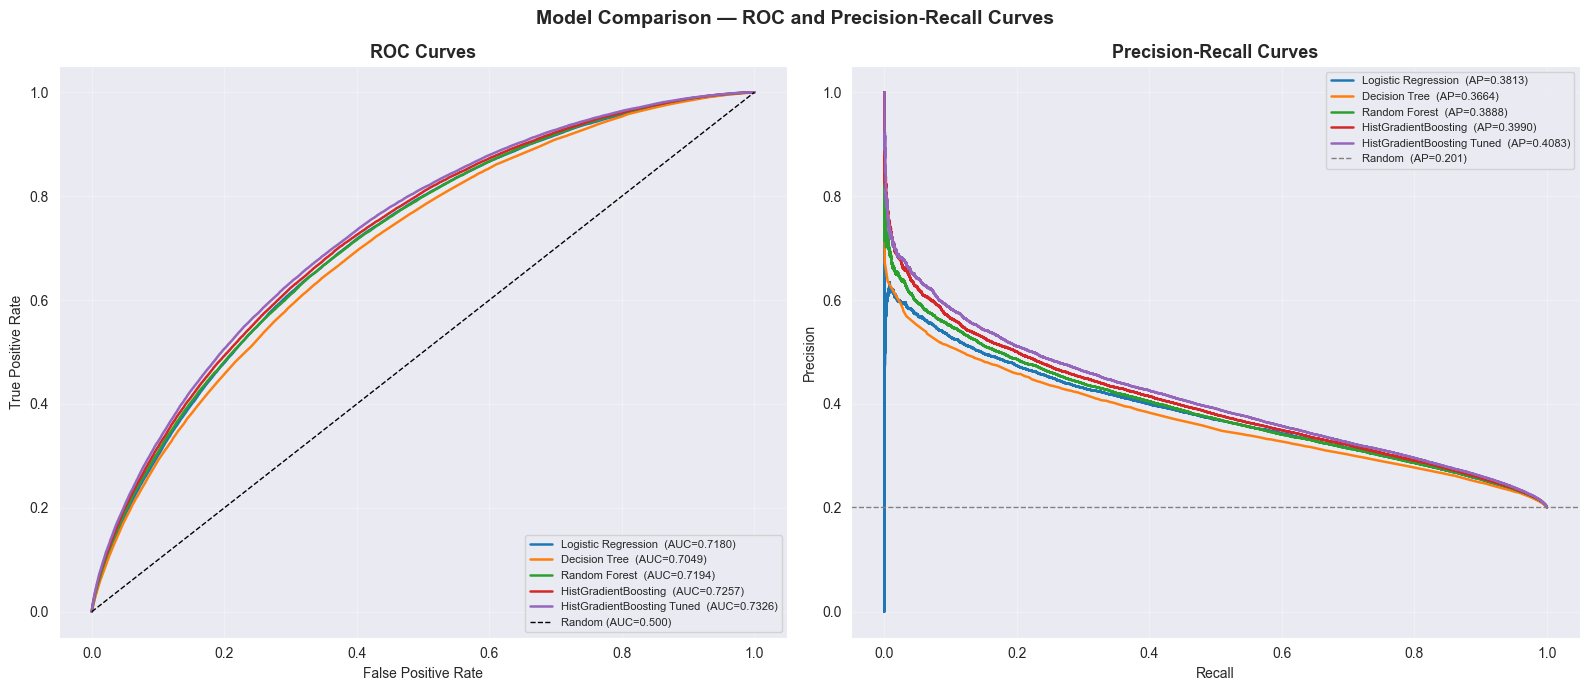

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
ax = axes[0]
for name, y_prob in models_plot.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, linewidth=1.8, label=f'{name}  (AUC={auc_score:.4f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC=0.500)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves', fontsize=13, fontweight='bold')
ax.legend(fontsize=8, loc='lower right')
ax.grid(True, alpha=0.3)

# PR curves
ax = axes[1]
baseline_precision = y_test.mean()

for name, y_prob in models_plot.items():
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    ap_score     = average_precision_score(y_test, y_prob)
    ax.plot(rec, prec, linewidth=1.8, label=f'{name}  (AP={ap_score:.4f})')

ax.axhline(baseline_precision, color='gray', linestyle='--', linewidth=1,
           label=f'Random  (AP={baseline_precision:.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves', fontsize=13, fontweight='bold')
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, alpha=0.3)

plt.suptitle('Model Comparison — ROC and Precision-Recall Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Both curves tell a consistent story.

On the ROC plot the five models are tightly clustered the gap between the best (HistGradientBoosting Tuned, 0.733) and the worst (Decision Tree, 0.705) is narrow across the full threshold range. All models separate meaningfully from the random baseline, but none dominates decisively.

The PR curve is more informative. At low recall levels (right side of the plot) precision drops sharply for all models even the best model cannot maintain high precision once it starts flagging more than a small fraction of loans as defaults. This is the fundamental difficulty of this dataset: the two classes overlap heavily in feature space, and the model is forced to accept more false positives to increase recall. The gap between models is slightly more visible here than on the ROC plot, with the tuned HistGradientBoosting consistently above the others across the recall range.


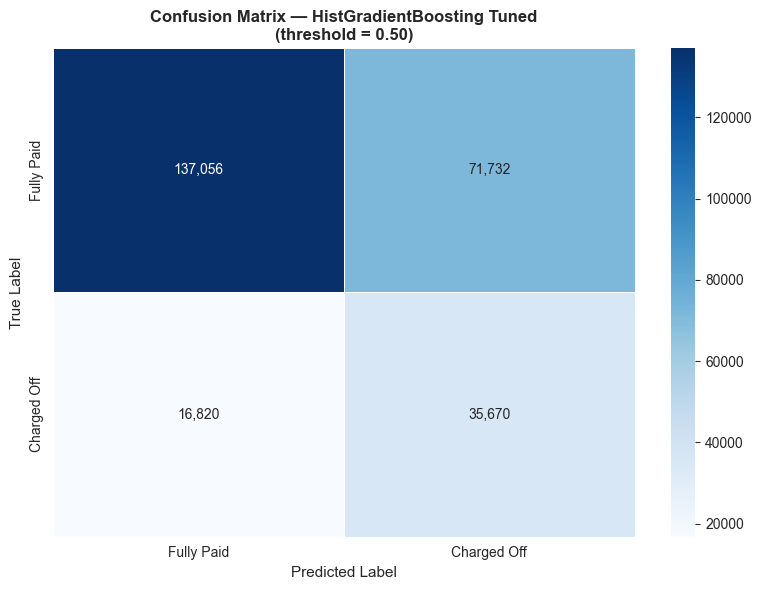

True Negatives  (correctly approved):  137,056
False Positives (good borrowers rejected):   71,732
False Negatives (missed defaults):   16,820
True Positives  (caught defaults):   35,670

Default catch rate (Recall): 67.96%
False alarm rate: 34.36%


In [65]:
# Confusion Matrix
cm     = confusion_matrix(y_test, y_pred_tuned)
labels = ['Fully Paid', 'Charged Off']

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt=',', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            linewidths=0.5, ax=ax)

ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)
ax.set_title('Confusion Matrix — HistGradientBoosting Tuned\n(threshold = 0.50)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Print raw numbers for reference
tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (correctly approved): {tn:>8,}')
print(f'False Positives (good borrowers rejected): {fp:>8,}')
print(f'False Negatives (missed defaults): {fn:>8,}')
print(f'True Positives  (caught defaults): {tp:>8,}')
print()
print(f'Default catch rate (Recall): {tp / (tp + fn):.2%}')
print(f'False alarm rate: {fp / (fp + tn):.2%}')

At the default 0.5 threshold the model catches 35,670 out of 52,490 actual defaults a recall of 68%. The cost is 71,732 good borrowers incorrectly flagged as risky, giving a false alarm rate of 34%.

In practical terms: for every 3 defaults the model catches, it also wrongly rejects roughly 2 good borrowers. Whether that tradeoff is acceptable depends entirely on the relative cost of each error a missed default costs the full loan amount, while a rejected good borrower costs the expected interest income. This is explored in Section 11.

The 16,820 missed defaults are the most expensive errors. These are loans the model approved that ended up charging off capital lost with no warning.

### 10.4 Feature Importance

`HistGradientBoostingClassifier` exposes feature importances based on the total gain each feature contributes across all splits in all trees. Higher importance means the feature was used more often and produced larger reductions in the loss function.

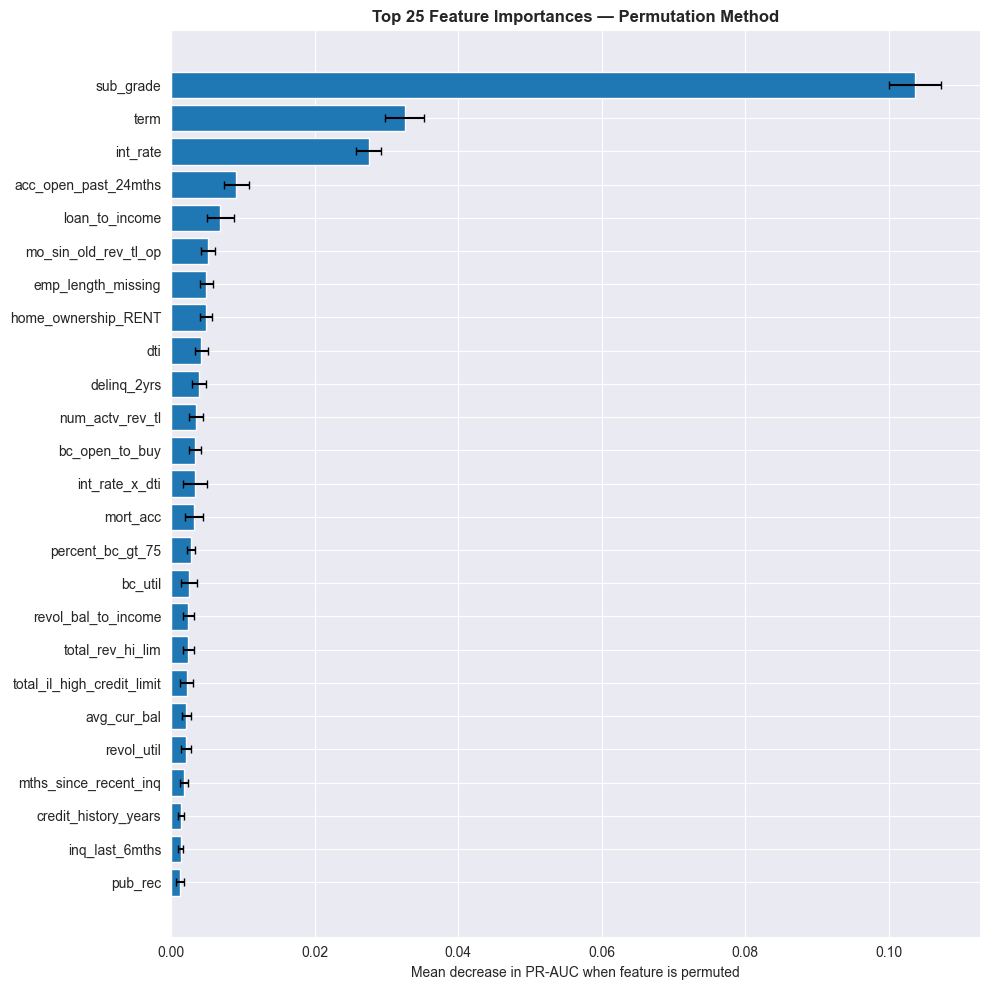

                   Feature  Importance      Std
                 sub_grade    0.103705 0.003662
                      term    0.032582 0.002706
                  int_rate    0.027539 0.001712
      acc_open_past_24mths    0.009095 0.001755
            loan_to_income    0.006835 0.001889
      mo_sin_old_rev_tl_op    0.005096 0.000971
        emp_length_missing    0.004904 0.000885
       home_ownership_RENT    0.004887 0.000871
                       dti    0.004204 0.000905
               delinq_2yrs    0.003878 0.000984
           num_actv_rev_tl    0.003419 0.000985
            bc_open_to_buy    0.003312 0.000881
            int_rate_x_dti    0.003311 0.001718
                  mort_acc    0.003199 0.001234
          percent_bc_gt_75    0.002776 0.000515
                   bc_util    0.002533 0.001093
       revol_bal_to_income    0.002412 0.000795
          total_rev_hi_lim    0.002363 0.000760
total_il_high_credit_limit    0.002155 0.000892
               avg_cur_bal    0.002140 0

In [66]:
# 10.4  Feature Importance — Permutation Importance
from sklearn.inspection import permutation_importance

# Reconstruct feature names after ColumnTransformer
ohe_feature_names = (preprocessor
                     .named_transformers_['cat']
                     .named_steps['onehot']
                     .get_feature_names_out(rare_group_cols)
                     .tolist())

feature_names = numeric_cols_pipe + ordinal_cols + ohe_feature_names

# Permutation importance on a 20K sample of the test set full test set is slow
sample_idx = np.random.RandomState(SEED).choice(len(X_test_processed), size=20000, replace=False)

result = permutation_importance(
    hgb_tuned,
    X_test_processed[sample_idx],
    y_test.iloc[sample_idx],
    n_repeats  = 10,           # shuffle each feature 10 times, take the mean
    scoring    = 'average_precision',
    n_jobs     = -1,
    random_state = SEED
)

importance_df = (pd.DataFrame({
                    'Feature'    : feature_names,
                    'Importance' : result.importances_mean,
                    'Std'        : result.importances_std
                })
                .sort_values('Importance', ascending=False)
                .head(25)
                .reset_index(drop=True))

# Plot top 25
fig, ax = plt.subplots(figsize=(10, 10))
ax.barh(importance_df['Feature'][::-1],
        importance_df['Importance'][::-1],
        xerr=importance_df['Std'][::-1],
        capsize=3)

ax.set_xlabel('Mean decrease in PR-AUC when feature is permuted')
ax.set_title('Top 25 Feature Importances — Permutation Method',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(importance_df.to_string(index=False))

The permutation importance results are clear and financially sensible.

`sub_grade` dominates by a wide margin removing it causes a 0.103 drop in PR-AUC, more than three times the next feature. This is not surprising.

`term` and `int_rate` follow at 0.033 and 0.027. Both are directly related to sub_grade longer terms and higher rates correlate with higher grades but they still carry independent signal after sub_grade is accounted for.

The engineered features `loan_to_income`, `int_rate_x_dti`, and `revol_bal_to_income` all appear in the top 25, confirming that the ratio features added real predictive value beyond the raw columns they were derived from.

`emp_length_missing` ranks 7th the binary flag indicating unreported employment length is more informative than the length itself. Borrowers who don't report employment are a distinct risk group.

The OHE features for `home_ownership` and `addr_state` appear but rank lower, consistent with the EDA findings where home ownership showed a meaningful but not dominant effect on default rate.

## 11. Business Impact Analysis <a id="11-business-impact-analysis"></a>

Metrics like PR-AUC and F1 are useful for comparing models but they don't translate directly into a business decision. A lender needs to know: at a given threshold, how much capital is saved by catching defaults, and how much revenue is lost by rejecting good borrowers?

I frame this as a threshold analysis. The default 0.5 threshold is arbitrary the optimal threshold depends on the relative cost of each type of error.

Assumptions:
 Average loan amount: $14,406
 Loss Given Default: 60% of loan amount
 Cost of missed default (FN) : $8,643
 Average interest rate: 13.26%
 Revenue lost per rejected good borrower (FP): $5,730



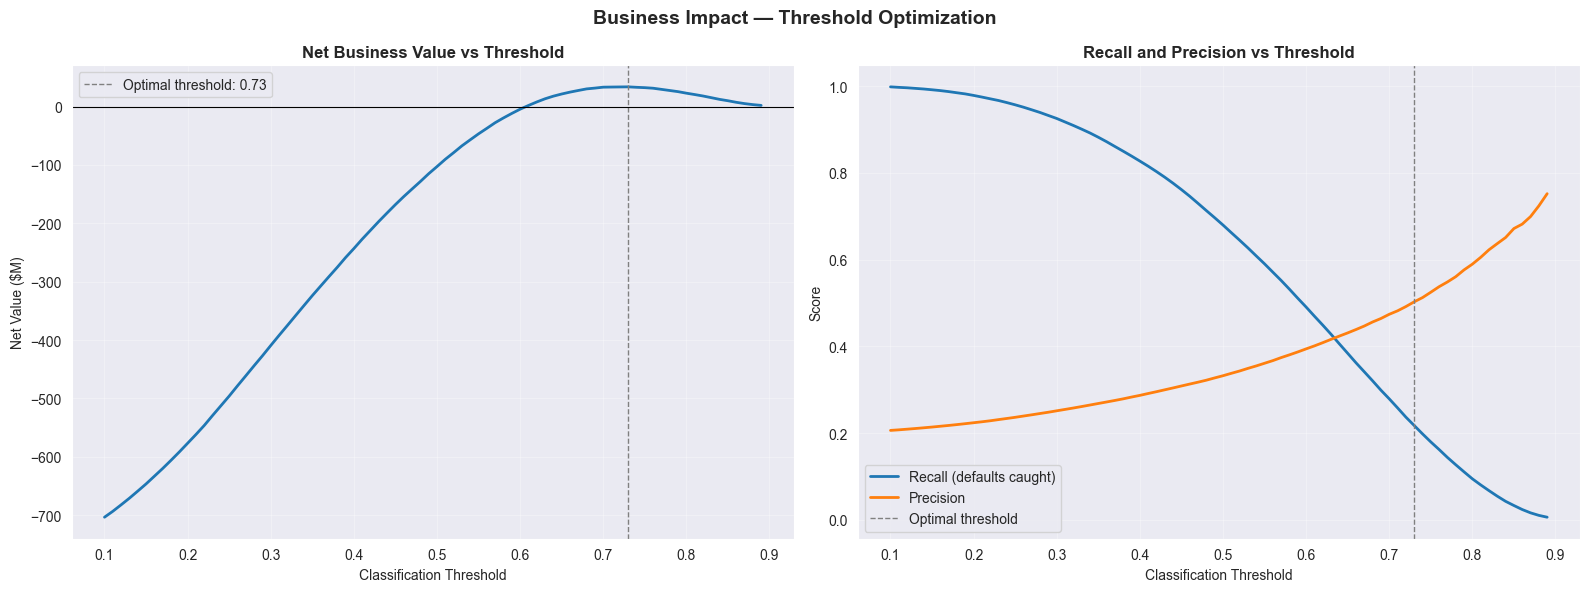

Optimal threshold: 0.73
Recall at optimal: 21.75%
Precision at opt: 50.25%
Capital saved: $98.7M
Revenue lost: $64.8M
Net value: $33.9M


In [67]:
# Threshold Analysis

# Assumptions
avg_loan_amount = loans['loan_amnt'].mean()    # average loan size in the dataset
lgd = 0.60                          # Loss Given Default 60% of loan amount lost
avg_interest_rate = loans['int_rate'].mean() / 100
loan_term_years = 3                             # approximate average term

# Expected interest income per good loan approved (simple approximation)
interest_income = avg_loan_amount * avg_interest_rate * loan_term_years

print(f"Assumptions:")
print(f" Average loan amount: ${avg_loan_amount:,.0f}")
print(f" Loss Given Default: {lgd:.0%} of loan amount")
print(f" Cost of missed default (FN) : ${avg_loan_amount * lgd:,.0f}")
print(f" Average interest rate: {avg_interest_rate:.2%}")
print(f" Revenue lost per rejected good borrower (FP): ${interest_income:,.0f}")
print()

# Sweep thresholds
thresholds = np.arange(0.10, 0.90, 0.01)
results_biz = []

for thresh in thresholds:
    y_pred_t = (y_prob_tuned >= thresh).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()

    capital_saved = tp * avg_loan_amount * lgd    # defaults caught × loss avoided
    revenue_lost = fp * interest_income # good borrowers rejected × interest lost
    net_value = capital_saved - revenue_lost

    results_biz.append({
        'Threshold': round(thresh, 2),
        'Recall': tp / (tp + fn),
        'Precision': tp / (tp + fp) if (tp + fp) > 0 else 0,
        'FP': fp,
        'FN': fn,
        'Capital Saved': capital_saved,
        'Revenue Lost': revenue_lost,
        'Net Value': net_value,
    })

biz_df = pd.DataFrame(results_biz)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Net value vs threshold
ax = axes[0]
ax.plot(biz_df['Threshold'], biz_df['Net Value'] / 1e6, linewidth=2)
ax.axvline(biz_df.loc[biz_df['Net Value'].idxmax(), 'Threshold'],
           linestyle='--', color='gray', linewidth=1,
           label=f"Optimal threshold: {biz_df.loc[biz_df['Net Value'].idxmax(), 'Threshold']:.2f}")
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Classification Threshold')
ax.set_ylabel('Net Value ($M)')
ax.set_title('Net Business Value vs Threshold', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Recall and Precision vs threshold
ax = axes[1]
ax.plot(biz_df['Threshold'], biz_df['Recall'],    linewidth=2, label='Recall (defaults caught)')
ax.plot(biz_df['Threshold'], biz_df['Precision'], linewidth=2, label='Precision')
ax.axvline(biz_df.loc[biz_df['Net Value'].idxmax(), 'Threshold'],
           linestyle='--', color='gray', linewidth=1, label='Optimal threshold')
ax.set_xlabel('Classification Threshold')
ax.set_ylabel('Score')
ax.set_title('Recall and Precision vs Threshold', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('Business Impact — Threshold Optimization', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Best threshold
best_row = biz_df.loc[biz_df['Net Value'].idxmax()]
print(f"Optimal threshold: {best_row['Threshold']:.2f}")
print(f"Recall at optimal: {best_row['Recall']:.2%}")
print(f"Precision at opt: {best_row['Precision']:.2%}")
print(f"Capital saved: ${best_row['Capital Saved']/1e6:.1f}M")
print(f"Revenue lost: ${best_row['Revenue Lost']/1e6:.1f}M")
print(f"Net value: ${best_row['Net Value']/1e6:.1f}M")

The threshold analysis reveals something important: the default 0.5 threshold is not the optimal business decision. The optimal threshold is 0.73 considerably more conservative than the default.

The net value curve peaks at $33.9M $98.7M in capital saved minus $64.8М in foregone interest income. Below threshold 0.73 the curve drops sharply into negative territory: the model flags so many good borrowers that the lost revenue outweighs the capital saved. Above 0.73 the model becomes too conservative and misses too many defaults.

Two important caveats. First, these numbers depend heavily on the LGD assumption of 60% a different recovery rate shifts the optimal threshold. Second, the analysis treats every loan as identical in size; in practice a lender would weight decisions by loan amount rather than loan count.

## 12. Conclusions and Limitations <a id="12-conclusions-and-limitations"></a>

### 12.1 What the Model Learned

The best model HistGradientBoosting with tuned hyperparameters achieves ROC-AUC 0.733 and PR-AUC 0.409 on the held-out test set. These numbers are consistent with published results on the same Lending Club dataset and reflect the genuine difficulty of the problem rather than a modeling failure.

The permutation importance analysis made one thing unmistakable: `sub_grade` accounts for more predictive power than the next three features combined. The model is largely learning to refine the platform's existing risk assessment at the margin, not to discover fundamentally new signals.

Beyond sub_grade, the features that matter most are `term`, `int_rate`, and the engineered ratio features particularly `loan_to_income` and `int_rate_x_dti`. Both ratios capture financial stress that the raw columns do not express on their own, confirming that feature engineering added real value.

The threshold analysis showed that the optimal operating point for a lender is not the default 0.5 but 0.73 a conservative threshold that trades recall for precision.

### 12.2 Limitations

**The ceiling is the data, not the model.** All five models converge to a similar PR-AUC range (0.37–0.41). A 300-tree gradient boosting ensemble barely outperforms Logistic Regression on ranking ability. This means the signal available in origination-time features is limited the most informative variables about whether someone will default are behavioral ones that only emerge after the loan is active.

**Class overlap is fundamental.** The borrowers who default look very similar to the borrowers who don't at the time of application.

**The business impact analysis makes simplifying assumptions.** A uniform LGD of 60% and a fixed interest income estimate per loan ignore the variation in loan size, actual recovery rates, and the time value of money.

## 13. References <a id="13-references"></a>

**Dataset**

wordsforthewise. (2019). *All Lending Club loan data, 2007–2018* [Dataset]. Kaggle.
https://www.kaggle.com/datasets/wordsforthewise/lending-club

---

**Papers**

Breiman, L. (2001). Random forests. *Machine Learning*, *45*(1), 5–32.
https://doi.org/10.1023/A:1010933404324

Friedman, J. H. (2001). Greedy function approximation: A gradient boosting machine. *The Annals of Statistics*, *29*(5), 1189–1232.
https://doi.org/10.1214/aos/1013203451

Pedregosa, F., Varoquaux, G., Gramfort, A., et al. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, *12*, 2825–2830.
https://jmlr.org/papers/v12/pedregosa11a.html

---

**Software**

scikit-learn developers. (2024). *scikit-learn* (Version 1.5).
https://scikit-learn.org/stable/